<a href="https://colab.research.google.com/github/halimAhtasham/Algorithm_Exercise/blob/main/config.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# 01. CONFIGURATION & REPRODUCIBILITY
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch

# -----------------------------
# Random seed
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Make experiments as reproducible as possible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -----------------------------
# Device
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cpu
Device: cpu


In [ ]:
# ============================================================
# 02. REQUIRED LIBRARIES
# ============================================================

!pip -q install shap scikit-learn scipy pandas numpy matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ============================================================
# 03. LOAD DATASET
# ============================================================
DATA_PATH = "/content/drive/MyDrive/Datasets/ROSIDS23.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

In [ ]:
# ============================================
# STEP 4.1 — Dataset Inspection
# ============================================

data = df.copy()

print("Original shape:", data.shape)

print("\nLabel distribution:")
print(data["Label"].value_counts())

print("\nMissing values:")
print(data.isnull().sum().sum())

print("\nInfinite values:")
print(np.isinf(data.select_dtypes(include=np.number)).sum().sum())

In [ ]:
# ============================================
# STEP 4.2 — Remove Non-Predictive Identifiers
# ============================================

# Columns that should NOT be used as ML features
identifier_columns = [
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Timestamp"
]

data = data.drop(columns=identifier_columns)

print("Shape after removing identifiers:", data.shape)

print("\nRemaining columns:")
print(data.columns.tolist())

In [ ]:
# ============================================
# STEP 4.3 — Convert to Binary Classification
# ============================================

# Benign = 0
# Any other class = Attack = 1

data["Binary_Label"] = (data["Label"] != "Benign").astype(int)

# Remove original multiclass label
data = data.drop(columns=["Label"])

print("Binary label distribution:")
print(data["Binary_Label"].value_counts())

print("\nFinal dataset shape:", data.shape)

In [ ]:
# ============================================
# STEP 4.4 — Handle Infinite Values
# ============================================

# Convert +inf and -inf into NaN
data = data.replace([np.inf, -np.inf], np.nan)

print("Total missing values after replacing infinity:")
print(data.isnull().sum().sum())

In [ ]:
missing_columns = data.isnull().sum()

missing_columns = missing_columns[missing_columns > 0]

print("Columns containing missing values:")
print(missing_columns)

In [ ]:
# ============================================
# STEP 5.1 — Separate Features and Target
# ============================================

X = data.drop(columns=["Binary_Label"])
y = data["Binary_Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

In [ ]:
# ============================================
# STEP 5.2 — First Train/Test Split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

print("Training set:", X_train.shape)
print("Temporary set:", X_temp.shape)

In [ ]:
# ============================================
# STEP 5.3 — Validation/Test Split
# ============================================

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

In [ ]:
# ============================================
# STEP 5.4 — Verify Stratification
# ============================================

print("\nTrain attack ratio:", y_train.mean())
print("Validation attack ratio:", y_val.mean())
print("Test attack ratio:", y_test.mean())

print("\nClass counts:")
print("Train:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTest:")
print(y_test.value_counts())

In [ ]:
# ============================================
# STEP 6.1 — Train-Only Missing Value Imputation
# ============================================

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

# FIT ONLY on training data
X_train_imputed = imputer.fit_transform(X_train)

# Transform validation and test using training statistics
X_val_imputed = imputer.transform(X_val)
X_test_imputed = imputer.transform(X_test)

print("Missing values after imputation:")
print("Train:", np.isnan(X_train_imputed).sum())
print("Validation:", np.isnan(X_val_imputed).sum())
print("Test:", np.isnan(X_test_imputed).sum())

In [ ]:
# ============================================
# STEP 6.2 — Train-Only Feature Scaling
# ============================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# FIT ONLY on training data
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Transform validation and test
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Scaled shapes:")
print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

In [ ]:
# ============================================
# STEP 6.3 — Final Preprocessing Check
# ============================================

print("Train min:", X_train_scaled.min())
print("Train max:", X_train_scaled.max())

print("\nValidation min:", X_val_scaled.min())
print("Validation max:", X_val_scaled.max())

print("\nTest min:", X_test_scaled.min())
print("Test max:", X_test_scaled.max())

print("\nAny NaN?")
print("Train:", np.isnan(X_train_scaled).any())
print("Validation:", np.isnan(X_val_scaled).any())
print("Test:", np.isnan(X_test_scaled).any())

In [ ]:
# ============================================
# STEP 7.1 — Convert Data to PyTorch
# ============================================

import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

print("Train:", X_train_tensor.shape, y_train_tensor.shape)
print("Validation:", X_val_tensor.shape, y_val_tensor.shape)
print("Test:", X_test_tensor.shape, y_test_tensor.shape)

In [ ]:
# ============================================
# STEP 7.2 — Create DataLoaders
# ============================================

BATCH_SIZE = 256

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches:", len(test_loader))

In [ ]:
# ============================================
# STEP 7.3 — Neural IDS Model
# ============================================

import torch.nn as nn

class IDSModel(nn.Module):

    def __init__(self, input_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


input_features = X_train_scaled.shape[1]

ids_model = IDSModel(input_features).to(DEVICE)

print(ids_model)

In [ ]:
# ============================================
# STEP 7.4 — Loss and Optimizer
# ============================================

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    ids_model.parameters(),
    lr=0.001
)

print("Loss:", criterion)
print("Optimizer:", optimizer)

In [ ]:
# ============================================
# STEP 7.5 — Training Function
# ============================================

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0.0

    for features, labels in loader:

        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(features)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * features.size(0)

    average_loss = total_loss / len(loader.dataset)

    return average_loss

In [ ]:
# ============================================
# STEP 7.6 — Validation Function
# ============================================

def evaluate_loss(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for features, labels in loader:

            features = features.to(device)
            labels = labels.to(device)

            logits = model(features)

            loss = criterion(logits, labels)

            total_loss += loss.item() * features.size(0)

    average_loss = total_loss / len(loader.dataset)

    return average_loss

In [ ]:
# ============================================
# STEP 7.7 — Train IDS
# ============================================

EPOCHS = 20

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        ids_model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss = evaluate_loss(
        ids_model,
        val_loader,
        criterion,
        DEVICE
    )

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

In [ ]:
# ============================================
# STEP 8.1 — Generate Test Predictions
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

def get_predictions(model, loader, device):

    model.eval()

    all_probabilities = []
    all_labels = []

    with torch.no_grad():

        for features, labels in loader:

            features = features.to(device)

            logits = model(features)

            probabilities = torch.sigmoid(logits)

            all_probabilities.extend(
                probabilities.cpu().numpy().flatten()
            )

            all_labels.extend(
                labels.numpy().flatten()
            )

    return np.array(all_labels), np.array(all_probabilities)


y_test_true, y_test_probability = get_predictions(
    ids_model,
    test_loader,
    DEVICE
)

y_test_pred = (y_test_probability >= 0.5).astype(int)

In [ ]:
# ============================================
# STEP 8.2 — Clean IDS Baseline Metrics
# ============================================

accuracy = accuracy_score(y_test_true, y_test_pred)

precision = precision_score(y_test_true, y_test_pred)

recall = recall_score(y_test_true, y_test_pred)

f1 = f1_score(y_test_true, y_test_pred)

roc_auc = roc_auc_score(
    y_test_true,
    y_test_probability
)

pr_auc = average_precision_score(
    y_test_true,
    y_test_probability
)

print("========== CLEAN IDS BASELINE ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

In [ ]:
# ============================================
# STEP 8.3 — Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_test_true,
    y_test_pred
)

print("Confusion Matrix:")
print(cm)

In [ ]:
# ============================================
# STEP 9.1 — Extract Hidden Representation
# ============================================

class IDSFeatureExtractor(nn.Module):

    def __init__(self, trained_model):
        super().__init__()

        self.feature_network = nn.Sequential(
            *list(trained_model.network.children())[:-1]
        )

    def forward(self, x):
        return self.feature_network(x)


feature_extractor = IDSFeatureExtractor(ids_model).to(DEVICE)

feature_extractor.eval()

print(feature_extractor)

In [ ]:
# ============================================
# STEP 9.2 — Correctly Classified Benign Data
# ============================================

ids_model.eval()

with torch.no_grad():

    train_logits = ids_model(X_train_tensor.to(DEVICE))

    train_probabilities = torch.sigmoid(train_logits).cpu().numpy().flatten()

train_predictions = (train_probabilities >= 0.5).astype(int)

train_labels = y_train.values

correct_benign_mask = (
    (train_labels == 0) &
    (train_predictions == 0)
)

X_benign_correct = X_train_tensor[correct_benign_mask]

print("Total benign training samples:",
      (train_labels == 0).sum())

print("Correctly classified benign samples:",
      correct_benign_mask.sum())

print("Reconstruction input shape:",
      X_benign_correct.shape)

In [ ]:
# ============================================
# STEP 9.3 — Extract Benign Representations
# ============================================

with torch.no_grad():

    benign_representations = feature_extractor(
        X_benign_correct.to(DEVICE)
    ).cpu().numpy()

print("Benign representation shape:",
      benign_representations.shape)

In [ ]:
# ============================================
# STEP 10 — READ Reconstruction Model
# ============================================

from sklearn.linear_model import LinearRegression

# Get correctly classified benign TRAINING samples
correct_benign_mask = (
    (y_train.values == 0) &
    (train_predictions == 0)
)

X_benign_correct = X_train_scaled[correct_benign_mask]

print("Correctly classified benign samples:", X_benign_correct.shape)

# Extract 32-D hidden representations
ids_model.eval()

with torch.no_grad():
    benign_representation_tensor = feature_extractor(
        torch.tensor(X_benign_correct, dtype=torch.float32).to(DEVICE)
    )

benign_representations = benign_representation_tensor.cpu().numpy()

print("Hidden representation shape:", benign_representations.shape)
print("Original feature shape:", X_benign_correct.shape)

In [ ]:
# ============================================
# STEP 10.1 — Reconstruction Train/Validation
# ============================================

from sklearn.model_selection import train_test_split

benign_rep_train, benign_rep_val, \
X_original_train, X_original_val = train_test_split(
    benign_representations,
    X_benign_correct,
    test_size=0.20,
    random_state=SEED
)

print("Reconstruction training:")
print("Hidden:", benign_rep_train.shape)
print("Original:", X_original_train.shape)

print("\nReconstruction validation:")
print("Hidden:", benign_rep_val.shape)
print("Original:", X_original_val.shape)

In [ ]:
# ============================================
# STEP 10.2 — Differentiable READ Reconstructor
# ============================================

import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class ReconstructionModel(nn.Module):
    def __init__(self, hidden_dim=32, output_dim=79):
        super().__init__()

        self.reconstructor = nn.Linear(
            hidden_dim,
            output_dim
        )

    def forward(self, hidden_representation):
        return self.reconstructor(hidden_representation)


reconstruction_model = ReconstructionModel(
    hidden_dim=32,
    output_dim=79
).to(DEVICE)

reconstruction_optimizer = torch.optim.Adam(
    reconstruction_model.parameters(),
    lr=0.001
)

reconstruction_criterion = nn.MSELoss()

RECONSTRUCTION_EPOCHS = 30
BATCH_SIZE = 256

In [ ]:
# ============================================
# STEP 10.3 — Reconstruction DataLoaders
# ============================================

rep_train_tensor = torch.tensor(
    benign_rep_train,
    dtype=torch.float32
)

original_train_tensor = torch.tensor(
    X_original_train,
    dtype=torch.float32
)

rep_val_tensor = torch.tensor(
    benign_rep_val,
    dtype=torch.float32
)

original_val_tensor = torch.tensor(
    X_original_val,
    dtype=torch.float32
)

reconstruction_train_dataset = TensorDataset(
    rep_train_tensor,
    original_train_tensor
)

reconstruction_val_dataset = TensorDataset(
    rep_val_tensor,
    original_val_tensor
)

reconstruction_train_loader = DataLoader(
    reconstruction_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

reconstruction_val_loader = DataLoader(
    reconstruction_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
# ============================================
# STEP 10.4 — Train Reconstruction Model
# ============================================

best_val_loss = float("inf")
best_state = None

for epoch in range(RECONSTRUCTION_EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    reconstruction_model.train()

    train_loss = 0.0

    for hidden_batch, original_batch in reconstruction_train_loader:

        hidden_batch = hidden_batch.to(DEVICE)
        original_batch = original_batch.to(DEVICE)

        reconstruction_optimizer.zero_grad()

        reconstructed = reconstruction_model(hidden_batch)

        loss = reconstruction_criterion(
            reconstructed,
            original_batch
        )

        loss.backward()
        reconstruction_optimizer.step()

        train_loss += loss.item() * hidden_batch.size(0)

    train_loss /= len(reconstruction_train_dataset)

    # -------------------------
    # Validation
    # -------------------------
    reconstruction_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for hidden_batch, original_batch in reconstruction_val_loader:

            hidden_batch = hidden_batch.to(DEVICE)
            original_batch = original_batch.to(DEVICE)

            reconstructed = reconstruction_model(
                hidden_batch
            )

            loss = reconstruction_criterion(
                reconstructed,
                original_batch
            )

            val_loss += loss.item() * hidden_batch.size(0)

    val_loss /= len(reconstruction_val_dataset)

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = {
            key: value.cpu().clone()
            for key, value
            in reconstruction_model.state_dict().items()
        }

    if (epoch + 1) % 5 == 0 or epoch == 0:

        print(
            f"Epoch {epoch+1:02d}/{RECONSTRUCTION_EPOCHS} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f}"
        )


# Load best model
reconstruction_model.load_state_dict(best_state)
reconstruction_model.to(DEVICE)

print("\nBest validation loss:", best_val_loss)

In [ ]:
# ============================================
# STEP 11 — Validate READ Reconstruction
# ============================================

reconstruction_model.eval()

with torch.no_grad():

    reconstructed_val = reconstruction_model(
        rep_val_tensor.to(DEVICE)
    ).cpu().numpy()

original_val = original_val_tensor.numpy()

# Absolute error for every feature
absolute_error = np.abs(
    original_val - reconstructed_val
)

# MedAE for every sample
benign_medae = np.median(
    absolute_error,
    axis=1
)

print("READ Reconstruction Error — Clean Benign Validation")
print("=" * 55)

print(f"Number of samples: {len(benign_medae)}")

print(f"\nMean   : {benign_medae.mean():.6f}")
print(f"Median : {np.median(benign_medae):.6f}")
print(f"Std    : {benign_medae.std():.6f}")
print(f"Min    : {benign_medae.min():.6f}")
print(f"Max    : {benign_medae.max():.6f}")

print("\nPercentiles:")

for percentile in [90, 95, 99, 99.5, 99.9]:

    print(
        f"{percentile}% : "
        f"{np.percentile(benign_medae, percentile):.6f}"
    )

In [ ]:
# ============================================
# STEP 12A — READ Uncertainty Functions
# ============================================

import numpy as np
import torch
from scipy.stats import entropy as scipy_entropy


def calculate_medae(original_data, reconstructed_data):
    """
    Calculate Median Absolute Error for each sample.
    """
    absolute_error = np.abs(
        original_data - reconstructed_data
    )

    return np.median(
        absolute_error,
        axis=1
    )


def calculate_mc_dropout_uncertainty(
    model,
    X,
    n_passes=20
):
    """
    Calculate:
    - Aleatoric uncertainty
    - Epistemic uncertainty
    - Predictive entropy

    using MC Dropout.
    """

    # Enable dropout during inference
    model.train()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    ).to(DEVICE)

    probability_samples = []

    with torch.no_grad():

        for _ in range(n_passes):

            logits = model(X_tensor)

            probabilities = torch.sigmoid(
                logits
            ).squeeze(1)

            probability_samples.append(
                probabilities.cpu().numpy()
            )

    probability_samples = np.stack(
        probability_samples,
        axis=0
    )

    # Mean prediction
    mean_probability = (
        probability_samples.mean(axis=0)
    )

    # Epistemic uncertainty
    epistemic_uncertainty = (
        probability_samples.var(axis=0)
    )

    # Aleatoric uncertainty
    aleatoric_uncertainty = (
        mean_probability *
        (1.0 - mean_probability)
    )

    # Predictive entropy
    probability_matrix = np.column_stack([
        1.0 - mean_probability,
        mean_probability
    ])

    predictive_entropy = scipy_entropy(
        probability_matrix.T + 1e-12,
        axis=0
    )

    # Return model to evaluation mode
    model.eval()

    return (
        aleatoric_uncertainty,
        epistemic_uncertainty,
        predictive_entropy
    )


print("Step 12A completed.")

In [ ]:
# ============================================
# STEP 12B — READ Metrics for Clean Benign
# ============================================

# --------------------------------------------
# 1. Original benign validation samples
# --------------------------------------------

X_benign_read = X_original_val

print("Input shape:", X_benign_read.shape)


# --------------------------------------------
# 2. Calculate MedAE
# --------------------------------------------

# reconstructed_val was generated in Step 11

benign_medae = calculate_medae(
    X_original_val,
    reconstructed_val
)


# --------------------------------------------
# 3. Calculate MC Dropout uncertainties
# --------------------------------------------

(
    benign_aleatoric,
    benign_epistemic,
    benign_entropy
) = calculate_mc_dropout_uncertainty(
    ids_model,
    X_benign_read,
    n_passes=20
)


# --------------------------------------------
# 4. Check shapes
# --------------------------------------------

print("\nMetric shapes:")
print("MedAE:", benign_medae.shape)
print("Aleatoric:", benign_aleatoric.shape)
print("Epistemic:", benign_epistemic.shape)
print("Entropy:", benign_entropy.shape)


# --------------------------------------------
# 5. Print statistics
# --------------------------------------------

print("\nREAD metrics — Clean Benign Samples")
print("=" * 55)

print(f"Number of samples: {len(X_benign_read)}")


print("\nMedAE:")
print(f"  Mean   : {benign_medae.mean():.6f}")
print(f"  Median : {np.median(benign_medae):.6f}")
print(f"  Std    : {benign_medae.std():.6f}")
print(f"  Min    : {benign_medae.min():.6f}")
print(f"  Max    : {benign_medae.max():.6f}")


print("\nAleatoric Uncertainty:")
print(f"  Mean   : {benign_aleatoric.mean():.6f}")
print(f"  Median : {np.median(benign_aleatoric):.6f}")
print(f"  Std    : {benign_aleatoric.std():.6f}")
print(f"  Min    : {benign_aleatoric.min():.6f}")
print(f"  Max    : {benign_aleatoric.max():.6f}")


print("\nEpistemic Uncertainty:")
print(f"  Mean   : {benign_epistemic.mean():.6f}")
print(f"  Median : {np.median(benign_epistemic):.6f}")
print(f"  Std    : {benign_epistemic.std():.6f}")
print(f"  Min    : {benign_epistemic.min():.6f}")
print(f"  Max    : {benign_epistemic.max():.6f}")


print("\nPredictive Entropy:")
print(f"  Mean   : {benign_entropy.mean():.6f}")
print(f"  Median : {np.median(benign_entropy):.6f}")
print(f"  Std    : {benign_entropy.std():.6f}")
print(f"  Min    : {benign_entropy.min():.6f}")
print(f"  Max    : {benign_entropy.max():.6f}")


print("\nStep 12B completed.")

In [ ]:
# ============================================
# STEP 13 — Correct Clean Attack Samples
# ============================================

# Use the PROCESSED + SCALED validation data
X_val_processed = X_val_scaled

y_val_array = (
    y_val.to_numpy()
    if hasattr(y_val, "to_numpy")
    else y_val
)

# Select attack samples
attack_mask_val = (y_val_array == 1)

X_attack_clean = X_val_processed[attack_mask_val]

print("Clean attack samples:", X_attack_clean.shape)

print(
    "NaN values:",
    np.isnan(X_attack_clean).sum()
)

print(
    "Infinite values:",
    np.isinf(X_attack_clean).sum()
)

In [ ]:
# ============================================
# STEP 13.1 — Extract Attack Representations
# ============================================

ids_model.eval()

X_attack_tensor = torch.tensor(
    X_attack_clean,
    dtype=torch.float32
).to(DEVICE)

with torch.no_grad():

    attack_representation_tensor = feature_extractor(
        X_attack_tensor
    )

attack_representations = (
    attack_representation_tensor
    .cpu()
    .numpy()
)

print("Attack input shape:", X_attack_clean.shape)
print(
    "Attack representation shape:",
    attack_representations.shape
)

print(
    "Representation NaN:",
    np.isnan(attack_representations).sum()
)

In [ ]:
# ============================================
# STEP 13 FIX — Check Validation Data
# ============================================

print("X_val NaN:", X_val.isna().sum().sum())
print("X_val Inf:", np.isinf(X_val.select_dtypes(include=np.number)).sum().sum())

print("\nX_val_imputed NaN:", np.isnan(X_val_imputed).sum())
print("X_val_imputed Inf:", np.isinf(X_val_imputed).sum())

print("\nX_val_scaled NaN:", np.isnan(X_val_scaled).sum())
print("X_val_scaled Inf:", np.isinf(X_val_scaled).sum())

In [ ]:
# ============================================
# STEP 13.2 — READ Metrics for Clean Attacks
# ============================================

# --------------------------------------------
# 1. Reconstruct attack samples
# --------------------------------------------

reconstruction_model.eval()

attack_rep_tensor = torch.tensor(
    attack_representations,
    dtype=torch.float32
).to(DEVICE)

with torch.no_grad():

    attack_reconstructed = reconstruction_model(
        attack_rep_tensor
    ).cpu().numpy()


# --------------------------------------------
# 2. Calculate MedAE
# --------------------------------------------

attack_medae = calculate_medae(
    X_attack_clean,
    attack_reconstructed
)


# --------------------------------------------
# 3. Calculate uncertainty metrics
# --------------------------------------------

(
    attack_aleatoric,
    attack_epistemic,
    attack_entropy
) = calculate_mc_dropout_uncertainty(
    ids_model,
    X_attack_clean,
    n_passes=20
)


# --------------------------------------------
# 4. Check for invalid values
# --------------------------------------------

print("NaN check:")
print("MedAE:", np.isnan(attack_medae).sum())
print("Aleatoric:", np.isnan(attack_aleatoric).sum())
print("Epistemic:", np.isnan(attack_epistemic).sum())
print("Entropy:", np.isnan(attack_entropy).sum())


# --------------------------------------------
# 5. Print statistics
# --------------------------------------------

print("\nREAD metrics — Clean Attack Samples")
print("=" * 55)

print(f"Number of samples: {len(X_attack_clean)}")

print("\nMedAE:")
print(f"  Mean   : {attack_medae.mean():.6f}")
print(f"  Median : {np.median(attack_medae):.6f}")
print(f"  Std    : {attack_medae.std():.6f}")

print("\nAleatoric Uncertainty:")
print(f"  Mean   : {attack_aleatoric.mean():.6f}")
print(f"  Median : {np.median(attack_aleatoric):.6f}")
print(f"  Std    : {attack_aleatoric.std():.6f}")

print("\nEpistemic Uncertainty:")
print(f"  Mean   : {attack_epistemic.mean():.6f}")
print(f"  Median : {np.median(attack_epistemic):.6f}")
print(f"  Std    : {attack_epistemic.std():.6f}")

print("\nPredictive Entropy:")
print(f"  Mean   : {attack_entropy.mean():.6f}")
print(f"  Median : {np.median(attack_entropy):.6f}")
print(f"  Std    : {attack_entropy.std():.6f}")

In [ ]:
# ============================================
# STEP 14 — Organize READ Metric Data
# ============================================

import numpy as np

# Clean benign metrics
benign_features = np.column_stack([
    benign_medae,
    benign_aleatoric,
    benign_epistemic,
    benign_entropy
])

# Clean attack metrics
attack_features = np.column_stack([
    attack_medae,
    attack_aleatoric,
    attack_epistemic,
    attack_entropy
])

print("Benign READ feature shape:", benign_features.shape)
print("Attack READ feature shape:", attack_features.shape)

print("\nFeature order:")
print([
    "MedAE",
    "Aleatoric",
    "Epistemic",
    "Entropy"
])

In [ ]:
import torch.nn.functional as F

def generate_fgsm_attack(
    model,
    X,
    y,
    epsilon=0.01
):
    """
    Generate epsilon-bounded untargeted FGSM attack.
    """

    model.eval()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
        device=DEVICE,
        requires_grad=True
    )

    y_tensor = torch.tensor(
        y,
        dtype=torch.float32,
        device=DEVICE
    ).view(-1, 1)

    logits = model(X_tensor)

    loss = F.binary_cross_entropy_with_logits(
        logits,
        y_tensor
    )

    model.zero_grad()
    loss.backward()

    gradient = X_tensor.grad.sign()

    # FGSM perturbation
    perturbation = epsilon * gradient

    # Apply perturbation
    X_adv = X_tensor + perturbation

    # Explicitly enforce epsilon bound
    delta = torch.clamp(
        X_adv - X_tensor,
        min=-epsilon,
        max=epsilon
    )

    X_adv = X_tensor + delta

    return X_adv.detach().cpu().numpy()

In [ ]:
# ============================================
# STEP 15.1 — Generate Correct FGSM
# ============================================

EPSILON = 0.01

X_attack_adv_fgsm = generate_fgsm_attack(
    ids_model,
    X_attack_clean,
    np.ones(len(X_attack_clean)),
    epsilon=EPSILON
)

perturbation = (
    X_attack_adv_fgsm -
    X_attack_clean
)

print("Original attack shape:",
      X_attack_clean.shape)

print("Adversarial attack shape:",
      X_attack_adv_fgsm.shape)

print(
    "Maximum perturbation:",
    np.max(np.abs(perturbation))
)

print(
    "Mean perturbation:",
    np.mean(np.abs(perturbation))
)

In [ ]:
# ============================================
# STEP 15.2 — Evaluate FGSM Against IDS
# ============================================

def get_predictions(model, X):
    model.eval()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    ).to(DEVICE)

    with torch.no_grad():
        logits = model(X_tensor)
        probabilities = torch.sigmoid(logits)

    return (
        probabilities.cpu().numpy().flatten()
    )


# Clean predictions
clean_probabilities = get_predictions(
    ids_model,
    X_attack_clean
)

clean_predictions = (
    clean_probabilities >= 0.5
).astype(int)


# Adversarial predictions
adv_probabilities = get_predictions(
    ids_model,
    X_attack_adv_fgsm
)

adv_predictions = (
    adv_probabilities >= 0.5
).astype(int)


# Attack Success Rate
originally_correct = (
    clean_predictions == 1
)

successfully_fooled = (
    adv_predictions == 0
)

attack_success_rate = (
    successfully_fooled[originally_correct].sum()
    / originally_correct.sum()
)


print("FGSM IDS Evaluation")
print("=" * 50)

print(
    f"Clean attack samples correctly classified: "
    f"{originally_correct.sum()}"
)

print(
    f"Adversarial samples classified as benign: "
    f"{successfully_fooled.sum()}"
)

print(
    f"Attack Success Rate: "
    f"{attack_success_rate * 100:.2f}%"
)

In [ ]:
# ============================================
# Step 15.3A — IDS Feature Extractor
# ============================================

class IDSFeatureExtractor(nn.Module):
    def __init__(self, ids_model):
        super().__init__()
        # Everything except the final output layer
        self.feature_layers = nn.Sequential(
            *list(ids_model.network.children())[:-1]
        )

    def forward(self, x):
        return self.feature_layers(x)


ids_feature_extractor = IDSFeatureExtractor(ids_model).to(DEVICE)
ids_feature_extractor.eval()

print("Feature extractor created successfully.")
print(ids_feature_extractor)

In [ ]:
# ============================================
# Step 15.3 — FGSM → READ Metrics
# ============================================

# Convert FGSM samples to tensor
fgsm_tensor = torch.tensor(
    X_attack_adv_fgsm,
    dtype=torch.float32
).to(DEVICE)

# Extract hidden representation
ids_feature_extractor.eval()

with torch.no_grad():
    fgsm_representation = ids_feature_extractor(fgsm_tensor).cpu().numpy()

print("FGSM adversarial input shape:", X_attack_adv_fgsm.shape)
print("FGSM representation shape:", fgsm_representation.shape)


# --------------------------------------------
# Reconstruct FGSM samples
# --------------------------------------------

fgsm_rep_tensor = torch.tensor(
    fgsm_representation,
    dtype=torch.float32
).to(DEVICE)

reconstruction_model.eval()

with torch.no_grad():
    fgsm_reconstructed = reconstruction_model(
        fgsm_rep_tensor
    ).cpu().numpy()


# --------------------------------------------
# Calculate MedAE
# --------------------------------------------

fgsm_medae = calculate_medae(
    X_attack_adv_fgsm,
    fgsm_reconstructed
)


# --------------------------------------------
# Calculate uncertainty metrics
# --------------------------------------------

fgsm_aleatoric, fgsm_epistemic, fgsm_entropy = (
    calculate_mc_dropout_uncertainty(
        ids_model,
        X_attack_adv_fgsm,
        n_passes=20
    )
)


# --------------------------------------------
# Combine READ metrics
# --------------------------------------------

fgsm_features = np.column_stack([
    fgsm_medae,
    fgsm_aleatoric,
    fgsm_epistemic,
    fgsm_entropy
])


# --------------------------------------------
# Check for NaN / Inf
# --------------------------------------------

print("\nNaN check:")
print("MedAE:", np.isnan(fgsm_medae).sum())
print("Aleatoric:", np.isnan(fgsm_aleatoric).sum())
print("Epistemic:", np.isnan(fgsm_epistemic).sum())
print("Entropy:", np.isnan(fgsm_entropy).sum())


# --------------------------------------------
# Summary
# --------------------------------------------

print("\nFGSM Adversarial READ Metrics")
print("==========================================")
print("Number:", len(fgsm_features))

print(
    f"MedAE      → Mean: {fgsm_medae.mean():.6f}, "
    f"Median: {np.median(fgsm_medae):.6f}, "
    f"Std: {fgsm_medae.std():.6f}"
)

print(
    f"Aleatoric  → Mean: {fgsm_aleatoric.mean():.6f}, "
    f"Median: {np.median(fgsm_aleatoric):.6f}, "
    f"Std: {fgsm_aleatoric.std():.6f}"
)

print(
    f"Epistemic  → Mean: {fgsm_epistemic.mean():.6f}, "
    f"Median: {np.median(fgsm_epistemic):.6f}, "
    f"Std: {fgsm_epistemic.std():.6f}"
)

print(
    f"Entropy    → Mean: {fgsm_entropy.mean():.6f}, "
    f"Median: {np.median(fgsm_entropy):.6f}, "
    f"Std: {fgsm_entropy.std():.6f}"
)

In [ ]:
# ============================================
# Step 15.4A — READ Detector Training Data (FIXED)
# ============================================

from sklearn.model_selection import train_test_split
import numpy as np

# ------------------------------------------------
# 1. Get correctly classified ATTACK training samples
#    (mirrors how X_benign_correct was built in Step 10,
#     but for the attack class instead of benign)
# ------------------------------------------------

correct_attack_mask_train = (
    (y_train.values == 1) &
    (train_predictions == 1)
)

X_attack_detector = X_train_scaled[correct_attack_mask_train]

print("Attack detector source:", X_attack_detector.shape)

# ------------------------------------------------
# 2. Generate FGSM using the CORRECT true label (1 = attack)
#    This pushes real attack traffic toward being
#    misclassified as benign -- the actual evasion threat.
# ------------------------------------------------

X_detector_fgsm = generate_fgsm_attack(
    ids_model,
    X_attack_detector,
    np.ones(len(X_attack_detector), dtype=int),   # true label IS attack
    epsilon=EPSILON
)

print("Generated FGSM samples:", X_detector_fgsm.shape)

# ------------------------------------------------
# 3. For a balanced detector training set, sample an equal
#    number of correctly-classified BENIGN training samples
#    (X_benign_correct already exists from Step 10)
# ------------------------------------------------

X_benign_correct_np = (
    X_benign_correct.cpu().numpy()
    if torch.is_tensor(X_benign_correct)
    else X_benign_correct
)

n_pairs = min(len(X_attack_detector), len(X_benign_correct_np))

rng = np.random.RandomState(SEED)
benign_idx = rng.choice(len(X_benign_correct_np), size=n_pairs, replace=False)
attack_idx = rng.choice(len(X_detector_fgsm), size=n_pairs, replace=False)

X_benign_detector = X_benign_correct_np[benign_idx]
X_detector_fgsm = X_detector_fgsm[attack_idx]

print("Balanced benign detector source:", X_benign_detector.shape)
print("Balanced FGSM detector source  :", X_detector_fgsm.shape)

Attack detector source: (50053, 79)
Generated FGSM samples: (50053, 79)
Balanced benign detector source: (42682, 79)
Balanced FGSM detector source  : (42682, 79)


In [ ]:
# ============================================
# Step 15.4B — Train READ Detector
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------
# 1. Calculate READ metrics for detector training
# ------------------------------------------------

benign_medae_train = calculate_medae(
    X_benign_detector,
    reconstruction_model(
        feature_extractor(
            torch.tensor(
                X_benign_detector,
                dtype=torch.float32,
                device=DEVICE
            )
        )
    ).detach().cpu().numpy()
)

# Attack/FGSM representations
attack_fgsm_tensor = torch.tensor(
    X_detector_fgsm,
    dtype=torch.float32,
    device=DEVICE
)

with torch.no_grad():
    attack_fgsm_representation = feature_extractor(
        attack_fgsm_tensor
    )

    attack_fgsm_reconstructed = reconstruction_model(
        attack_fgsm_representation
    )

attack_fgsm_reconstructed = (
    attack_fgsm_reconstructed
    .cpu()
    .numpy()
)

attack_fgsm_medae = calculate_medae(
    X_detector_fgsm,
    attack_fgsm_reconstructed
)

# ------------------------------------------------
# 2. Uncertainty metrics
# ------------------------------------------------

benign_aleatoric, benign_epistemic, benign_entropy = (
    calculate_mc_dropout_uncertainty(
        ids_model,
        X_benign_detector
    )
)

attack_fgsm_aleatoric, attack_fgsm_epistemic, attack_fgsm_entropy = (
    calculate_mc_dropout_uncertainty(
        ids_model,
        X_detector_fgsm
    )
)

# ------------------------------------------------
# 3. Build detector features
# ------------------------------------------------

benign_detector_features = np.column_stack([
    benign_medae_train,
    benign_aleatoric,
    benign_epistemic,
    benign_entropy
])

attack_detector_features = np.column_stack([
    attack_fgsm_medae,
    attack_fgsm_aleatoric,
    attack_fgsm_epistemic,
    attack_fgsm_entropy
])

X_read_detector = np.vstack([
    benign_detector_features,
    attack_detector_features
])

y_read_detector = np.concatenate([
    np.zeros(len(benign_detector_features), dtype=int),
    np.ones(len(attack_detector_features), dtype=int)
])

print("READ detector feature shape:", X_read_detector.shape)
print("READ detector label shape:", y_read_detector.shape)

READ detector feature shape: (85364, 4)
READ detector label shape: (85364,)


In [ ]:
# ============================================
# Step 15.4C — Train READ Detector
# ============================================

read_detector = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced"
)

read_detector.fit(
    X_read_detector,
    y_read_detector
)

print("READ detector retrained successfully.")

READ detector retrained successfully.


In [ ]:
# # ============================================
# # Step 15.4D — Train READ Detector
# # ============================================

# from sklearn.ensemble import RandomForestClassifier

# read_detector = RandomForestClassifier(
#     n_estimators=200,
#     random_state=SEED,
#     n_jobs=-1,
#     class_weight="balanced"
# )

# read_detector.fit(
#     X_read_train,
#     y_read_train
# )

# print("READ detector trained successfully.")

READ detector trained successfully.


In [ ]:
# ============================================
# Step 15.4E — READ Detector Evaluation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

read_predictions = read_detector.predict(X_read_val)
read_probabilities = read_detector.predict_proba(X_read_val)[:, 1]

print("READ Detector Evaluation")
print("==========================================")

print(
    "Accuracy :",
    f"{accuracy_score(y_read_val, read_predictions):.4f}"
)

print(
    "Precision:",
    f"{precision_score(y_read_val, read_predictions):.4f}"
)

print(
    "Recall   :",
    f"{recall_score(y_read_val, read_predictions):.4f}"
)

print(
    "F1       :",
    f"{f1_score(y_read_val, read_predictions):.4f}"
)

print(
    "ROC-AUC  :",
    f"{roc_auc_score(y_read_val, read_probabilities):.4f}"
)

print(
    "PR-AUC   :",
    f"{average_precision_score(y_read_val, read_probabilities):.4f}"
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_read_val, read_predictions))

READ Detector Evaluation
Accuracy : 0.9905
Precision: 1.0000
Recall   : 0.9809
F1       : 0.9904
ROC-AUC  : 0.9994
PR-AUC   : 0.9994

Confusion Matrix:
[[8537    0]
 [ 163 8373]]


In [ ]:
# ============================================
# Step 15.5 — READ Detection on Unseen FGSM
# ============================================

# Clean benign samples from the separate validation set
benign_eval_features = benign_features

# FGSM samples generated from separate IDS validation attacks
fgsm_eval_features = fgsm_features

# Combine evaluation data
X_read_eval = np.vstack([
    benign_eval_features,
    fgsm_eval_features
])

y_read_eval = np.concatenate([
    np.zeros(len(benign_eval_features), dtype=int),
    np.ones(len(fgsm_eval_features), dtype=int)
])

# Predict using the FROZEN READ detector
eval_predictions = read_detector.predict(X_read_eval)
eval_probabilities = read_detector.predict_proba(X_read_eval)[:, 1]

print("Unseen FGSM READ Evaluation")
print("==========================================")

print(
    "Accuracy :",
    f"{accuracy_score(y_read_eval, eval_predictions):.4f}"
)

print(
    "Precision:",
    f"{precision_score(y_read_eval, eval_predictions):.4f}"
)

print(
    "Recall   :",
    f"{recall_score(y_read_eval, eval_predictions):.4f}"
)

print(
    "F1       :",
    f"{f1_score(y_read_eval, eval_predictions):.4f}"
)

print(
    "ROC-AUC  :",
    f"{roc_auc_score(y_read_eval, eval_probabilities):.4f}"
)

print(
    "PR-AUC   :",
    f"{average_precision_score(y_read_eval, eval_probabilities):.4f}"
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_read_eval, eval_predictions))

Unseen FGSM READ Evaluation
Accuracy : 0.9689
Precision: 0.9832
Recall   : 0.9614
F1       : 0.9722
ROC-AUC  : 0.9926
PR-AUC   : 0.9942

Confusion Matrix:
[[ 8354   183]
 [  429 10696]]


In [ ]:
# ============================================
# Step 16.1 — BIM Attack
# ============================================

import torch.nn.functional as F

def generate_bim_attack(
    model,
    X,
    y,
    epsilon=0.01,
    alpha=0.002,
    num_iterations=5
):
    model.eval()

    X_original = torch.tensor(
        X,
        dtype=torch.float32,
        device=DEVICE
    )

    y_tensor = torch.tensor(
        y,
        dtype=torch.float32,
        device=DEVICE
    ).view(-1, 1)

    X_adv = X_original.clone().detach()

    for _ in range(num_iterations):

        X_adv.requires_grad_(True)

        logits = model(X_adv)

        loss = F.binary_cross_entropy_with_logits(
            logits,
            y_tensor
        )

        model.zero_grad()

        if X_adv.grad is not None:
            X_adv.grad.zero_()

        loss.backward()

        gradient = X_adv.grad.sign()

        # Iterative FGSM step
        X_adv = X_adv.detach() + alpha * gradient

        # Keep total perturbation within epsilon
        delta = torch.clamp(
            X_adv - X_original,
            min=-epsilon,
            max=epsilon
        )

        X_adv = X_original + delta

    return X_adv.detach().cpu().numpy()

In [ ]:
# ============================================
# Step 16.2 — Generate BIM
# ============================================

BIM_EPSILON = 0.01
BIM_ALPHA = 0.002
BIM_ITERATIONS = 5

X_attack_adv_bim = generate_bim_attack(
    ids_model,
    X_attack_clean,
    np.ones(len(X_attack_clean), dtype=int),
    epsilon=BIM_EPSILON,
    alpha=BIM_ALPHA,
    num_iterations=BIM_ITERATIONS
)

perturbation_bim = np.abs(
    X_attack_adv_bim - X_attack_clean
)

print("BIM adversarial shape:", X_attack_adv_bim.shape)
print(
    "Maximum perturbation:",
    perturbation_bim.max()
)
print(
    "Mean perturbation:",
    perturbation_bim.mean()
)

BIM adversarial shape: (11125, 79)
Maximum perturbation: 0.010000034962529991
Mean perturbation: 0.0033756545252025226


In [ ]:
# ============================================
# Step 16.3 — BIM IDS Evaluation
# ============================================

clean_probabilities = get_predictions(
    ids_model,
    X_attack_clean
)

clean_predictions = (
    clean_probabilities >= 0.5
).astype(int)

bim_probabilities = get_predictions(
    ids_model,
    X_attack_adv_bim
)

bim_predictions = (
    bim_probabilities >= 0.5
).astype(int)

originally_correct = (
    clean_predictions == 1
)

successfully_fooled = (
    bim_predictions == 0
)

bim_attack_success_rate = (
    successfully_fooled[originally_correct].sum()
    / originally_correct.sum()
)

print("BIM IDS Evaluation")
print("==================================================")
print(
    "Clean attack samples correctly classified:",
    originally_correct.sum()
)
print(
    "Adversarial samples classified as benign:",
    successfully_fooled.sum()
)
print(
    f"Attack Success Rate: "
    f"{bim_attack_success_rate * 100:.2f}%"
)

BIM IDS Evaluation
Clean attack samples correctly classified: 10728
Adversarial samples classified as benign: 3967
Attack Success Rate: 33.28%


In [ ]:
# ============================================
# Step 16.4 — BIM READ Metrics
# ============================================

bim_features = get_read_features(
    X_attack_adv_bim
)

bim_medae = bim_features[:, 0]
bim_aleatoric = bim_features[:, 1]
bim_epistemic = bim_features[:, 2]
bim_entropy = bim_features[:, 3]

print("\nBIM Adversarial READ Metrics")
print("==========================================")
print("Number:", len(bim_features))

print(
    f"MedAE      → Mean: {bim_medae.mean():.6f}, "
    f"Median: {np.median(bim_medae):.6f}, "
    f"Std: {bim_medae.std():.6f}"
)

print(
    f"Aleatoric  → Mean: {bim_aleatoric.mean():.6f}, "
    f"Median: {np.median(bim_aleatoric):.6f}, "
    f"Std: {bim_aleatoric.std():.6f}"
)

print(
    f"Epistemic  → Mean: {bim_epistemic.mean():.6f}, "
    f"Median: {np.median(bim_epistemic):.6f}, "
    f"Std: {bim_epistemic.std():.6f}"
)

print(
    f"Entropy    → Mean: {bim_entropy.mean():.6f}, "
    f"Median: {np.median(bim_entropy):.6f}, "
    f"Std: {bim_entropy.std():.6f}"
)


BIM Adversarial READ Metrics
Number: 11125
MedAE      → Mean: 0.164725, Median: 0.149867, Std: 0.134902
Aleatoric  → Mean: 0.011644, Median: 0.000000, Std: 0.041068
Epistemic  → Mean: 0.003164, Median: 0.000000, Std: 0.015219
Entropy    → Mean: 0.039621, Median: 0.000000, Std: 0.123770


In [ ]:
# ============================================
# Step 16.5 — BIM READ Detection
# ============================================

X_bim_read_eval = np.vstack([
    benign_features,
    bim_features
])

y_bim_read_eval = np.concatenate([
    np.zeros(len(benign_features), dtype=int),
    np.ones(len(bim_features), dtype=int)
])

bim_read_predictions = read_detector.predict(
    X_bim_read_eval
)

bim_read_probabilities = (
    read_detector.predict_proba(
        X_bim_read_eval
    )[:, 1]
)

print("BIM READ Evaluation")
print("==========================================")

print(
    "Accuracy :",
    f"{accuracy_score(y_bim_read_eval, bim_read_predictions):.4f}"
)

print(
    "Precision:",
    f"{precision_score(y_bim_read_eval, bim_read_predictions):.4f}"
)

print(
    "Recall   :",
    f"{recall_score(y_bim_read_eval, bim_read_predictions):.4f}"
)

print(
    "F1       :",
    f"{f1_score(y_bim_read_eval, bim_read_predictions):.4f}"
)

print(
    "ROC-AUC  :",
    f"{roc_auc_score(y_bim_read_eval, bim_read_probabilities):.4f}"
)

print(
    "PR-AUC   :",
    f"{average_precision_score(y_bim_read_eval, bim_read_probabilities):.4f}"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_bim_read_eval,
        bim_read_predictions
    )
)

BIM READ Evaluation
Accuracy : 0.9281
Precision: 0.9818
Recall   : 0.8893
F1       : 0.9333
ROC-AUC  : 0.9833
PR-AUC   : 0.9872

Confusion Matrix:
[[8354  183]
 [1231 9894]]


In [ ]:
# ============================================
# Step 17.1 — PGD Attack
# ============================================

def generate_pgd_attack(
    model,
    X,
    y,
    epsilon=0.01,
    alpha=0.002,
    num_iterations=5
):
    model.eval()

    X_original = torch.tensor(
        X,
        dtype=torch.float32,
        device=DEVICE
    )

    y_tensor = torch.tensor(
        y,
        dtype=torch.float32,
        device=DEVICE
    ).view(-1, 1)

    # Random initialization inside epsilon-ball
    random_delta = torch.empty_like(
        X_original
    ).uniform_(
        -epsilon,
        epsilon
    )

    X_adv = (
        X_original + random_delta
    ).detach()

    for _ in range(num_iterations):

        X_adv.requires_grad_(True)

        logits = model(X_adv)

        loss = F.binary_cross_entropy_with_logits(
            logits,
            y_tensor
        )

        model.zero_grad()

        if X_adv.grad is not None:
            X_adv.grad.zero_()

        loss.backward()

        gradient = X_adv.grad.sign()

        # Gradient ascent
        X_adv = (
            X_adv.detach()
            + alpha * gradient
        )

        # Project back into epsilon-ball
        delta = torch.clamp(
            X_adv - X_original,
            min=-epsilon,
            max=epsilon
        )

        X_adv = (
            X_original + delta
        ).detach()

    return X_adv.cpu().numpy()

In [ ]:
# ============================================
# Step 17.2 — Generate PGD
# ============================================

PGD_EPSILON = 0.01
PGD_ALPHA = 0.002
PGD_ITERATIONS = 5

X_attack_adv_pgd = generate_pgd_attack(
    ids_model,
    X_attack_clean,
    np.ones(len(X_attack_clean), dtype=int),
    epsilon=PGD_EPSILON,
    alpha=PGD_ALPHA,
    num_iterations=PGD_ITERATIONS
)

perturbation_pgd = np.abs(
    X_attack_adv_pgd - X_attack_clean
)

print("PGD adversarial shape:", X_attack_adv_pgd.shape)
print(
    "Maximum perturbation:",
    perturbation_pgd.max()
)
print(
    "Mean perturbation:",
    perturbation_pgd.mean()
)

PGD adversarial shape: (11125, 79)
Maximum perturbation: 0.010000079146391894
Mean perturbation: 0.005811792838972473


In [ ]:
# ============================================
# Step 17.3 — PGD IDS Evaluation
# ============================================

pgd_probabilities = get_predictions(
    ids_model,
    X_attack_adv_pgd
)

pgd_predictions = (
    pgd_probabilities >= 0.5
).astype(int)

successfully_fooled_pgd = (
    pgd_predictions == 0
)

pgd_attack_success_rate = (
    successfully_fooled_pgd[originally_correct].sum()
    / originally_correct.sum()
)

print("PGD IDS Evaluation")
print("==================================================")
print(
    "Clean attack samples correctly classified:",
    originally_correct.sum()
)
print(
    "Adversarial samples classified as benign:",
    successfully_fooled_pgd.sum()
)
print(
    f"Attack Success Rate: "
    f"{pgd_attack_success_rate * 100:.2f}%"
)

PGD IDS Evaluation
Clean attack samples correctly classified: 10728
Adversarial samples classified as benign: 3406
Attack Success Rate: 28.41%


In [ ]:
# ============================================
# Step 17.4 — PGD READ Metrics
# ============================================

pgd_features = get_read_features(
    X_attack_adv_pgd
)

pgd_medae = pgd_features[:, 0]
pgd_aleatoric = pgd_features[:, 1]
pgd_epistemic = pgd_features[:, 2]
pgd_entropy = pgd_features[:, 3]

print("\nPGD Adversarial READ Metrics")
print("==========================================")
print("Number:", len(pgd_features))

print(
    f"MedAE      → Mean: {pgd_medae.mean():.6f}, "
    f"Median: {np.median(pgd_medae):.6f}, "
    f"Std: {pgd_medae.std():.6f}"
)

print(
    f"Aleatoric  → Mean: {pgd_aleatoric.mean():.6f}, "
    f"Median: {np.median(pgd_aleatoric):.6f}, "
    f"Std: {pgd_aleatoric.std():.6f}"
)

print(
    f"Epistemic  → Mean: {pgd_epistemic.mean():.6f}, "
    f"Median: {np.median(pgd_epistemic):.6f}, "
    f"Std: {pgd_epistemic.std():.6f}"
)

print(
    f"Entropy    → Mean: {pgd_entropy.mean():.6f}, "
    f"Median: {np.median(pgd_entropy):.6f}, "
    f"Std: {pgd_entropy.std():.6f}"
)


PGD Adversarial READ Metrics
Number: 11125
MedAE      → Mean: 0.162980, Median: 0.146518, Std: 0.134968
Aleatoric  → Mean: 0.019293, Median: 0.000000, Std: 0.052098
Epistemic  → Mean: 0.004818, Median: 0.000000, Std: 0.017959
Entropy    → Mean: 0.064253, Median: 0.000003, Std: 0.156560


In [ ]:
# ============================================
# Step 17.5 — PGD READ Detection
# ============================================

X_pgd_read_eval = np.vstack([
    benign_features,
    pgd_features
])

y_pgd_read_eval = np.concatenate([
    np.zeros(len(benign_features), dtype=int),
    np.ones(len(pgd_features), dtype=int)
])

pgd_read_predictions = read_detector.predict(
    X_pgd_read_eval
)

pgd_read_probabilities = (
    read_detector.predict_proba(
        X_pgd_read_eval
    )[:, 1]
)

print("PGD READ Evaluation")
print("==========================================")

print(
    "Accuracy :",
    f"{accuracy_score(y_pgd_read_eval, pgd_read_predictions):.4f}"
)

print(
    "Precision:",
    f"{precision_score(y_pgd_read_eval, pgd_read_predictions):.4f}"
)

print(
    "Recall   :",
    f"{recall_score(y_pgd_read_eval, pgd_read_predictions):.4f}"
)

print(
    "F1       :",
    f"{f1_score(y_pgd_read_eval, pgd_read_predictions):.4f}"
)

print(
    "ROC-AUC  :",
    f"{roc_auc_score(y_pgd_read_eval, pgd_read_probabilities):.4f}"
)

print(
    "PR-AUC   :",
    f"{average_precision_score(y_pgd_read_eval, pgd_read_probabilities):.4f}"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_pgd_read_eval,
        pgd_read_predictions
    )
)

PGD READ Evaluation
Accuracy : 0.9299
Precision: 0.9819
Recall   : 0.8925
F1       : 0.9351
ROC-AUC  : 0.9790
PR-AUC   : 0.9842

Confusion Matrix:
[[8354  183]
 [1196 9929]]


In [ ]:
# ============================================
# Step 18 — Comparison Table
# ============================================

import pandas as pd

# Initialize a dictionary to store metrics
comparison_metrics = {}

# --- FGSM Metrics ---
comparison_metrics['FGSM'] = {
    'Attack Success Rate (IDS)': f"{attack_success_rate * 100:.2f}%",
    'READ Detector Accuracy': f"{accuracy_score(y_read_eval, eval_predictions):.4f}",
    'READ Detector Precision': f"{precision_score(y_read_eval, eval_predictions):.4f}",
    'READ Detector Recall': f"{recall_score(y_read_eval, eval_predictions):.4f}",
    'READ Detector F1': f"{f1_score(y_read_eval, eval_predictions):.4f}",
    'READ Detector ROC-AUC': f"{roc_auc_score(y_read_eval, eval_probabilities):.4f}",
    'READ Detector PR-AUC': f"{average_precision_score(y_read_eval, eval_probabilities):.4f}",
    'MedAE Mean': f"{fgsm_medae.mean():.6f}",
    'MedAE Median': f"{np.median(fgsm_medae):.6f}",
    'MedAE Std': f"{fgsm_medae.std():.6f}",
    'Aleatoric Mean': f"{fgsm_aleatoric.mean():.6f}",
    'Aleatoric Median': f"{np.median(fgsm_aleatoric):.6f}",
    'Aleatoric Std': f"{fgsm_aleatoric.std():.6f}",
    'Epistemic Mean': f"{fgsm_epistemic.mean():.6f}",
    'Epistemic Median': f"{np.median(fgsm_epistemic):.6f}",
    'Epistemic Std': f"{fgsm_epistemic.std():.6f}",
    'Entropy Mean': f"{fgsm_entropy.mean():.6f}",
    'Entropy Median': f"{np.median(fgsm_entropy):.6f}",
    'Entropy Std': f"{fgsm_entropy.std():.6f}"
}

# --- BIM Metrics ---
comparison_metrics['BIM'] = {
    'Attack Success Rate (IDS)': f"{bim_attack_success_rate * 100:.2f}%",
    'READ Detector Accuracy': f"{accuracy_score(y_bim_read_eval, bim_read_predictions):.4f}",
    'READ Detector Precision': f"{precision_score(y_bim_read_eval, bim_read_predictions):.4f}",
    'READ Detector Recall': f"{recall_score(y_bim_read_eval, bim_read_predictions):.4f}",
    'READ Detector F1': f"{f1_score(y_bim_read_eval, bim_read_predictions):.4f}",
    'READ Detector ROC-AUC': f"{roc_auc_score(y_bim_read_eval, bim_read_probabilities):.4f}",
    'READ Detector PR-AUC': f"{average_precision_score(y_bim_read_eval, bim_read_probabilities):.4f}",
    'MedAE Mean': f"{bim_medae.mean():.6f}",
    'MedAE Median': f"{np.median(bim_medae):.6f}",
    'MedAE Std': f"{bim_medae.std():.6f}",
    'Aleatoric Mean': f"{bim_aleatoric.mean():.6f}",
    'Aleatoric Median': f"{np.median(bim_aleatoric):.6f}",
    'Aleatoric Std': f"{bim_aleatoric.std():.6f}",
    'Epistemic Mean': f"{bim_epistemic.mean():.6f}",
    'Epistemic Median': f"{np.median(bim_epistemic):.6f}",
    'Epistemic Std': f"{bim_epistemic.std():.6f}",
    'Entropy Mean': f"{bim_entropy.mean():.6f}",
    'Entropy Median': f"{np.median(bim_entropy):.6f}",
    'Entropy Std': f"{bim_entropy.std():.6f}"
}

# --- PGD Metrics ---
comparison_metrics['PGD'] = {
    'Attack Success Rate (IDS)': f"{pgd_attack_success_rate * 100:.2f}%",
    'READ Detector Accuracy': f"{accuracy_score(y_pgd_read_eval, pgd_read_predictions):.4f}",
    'READ Detector Precision': f"{precision_score(y_pgd_read_eval, pgd_read_predictions):.4f}",
    'READ Detector Recall': f"{recall_score(y_pgd_read_eval, pgd_read_predictions):.4f}",
    'READ Detector F1': f"{f1_score(y_pgd_read_eval, pgd_read_predictions):.4f}",
    'READ Detector ROC-AUC': f"{roc_auc_score(y_pgd_read_eval, pgd_read_probabilities):.4f}",
    'READ Detector PR-AUC': f"{average_precision_score(y_pgd_read_eval, pgd_read_probabilities):.4f}",
    'MedAE Mean': f"{pgd_medae.mean():.6f}",
    'MedAE Median': f"{np.median(pgd_medae):.6f}",
    'MedAE Std': f"{pgd_medae.std():.6f}",
    'Aleatoric Mean': f"{pgd_aleatoric.mean():.6f}",
    'Aleatoric Median': f"{np.median(pgd_aleatoric):.6f}",
    'Aleatoric Std': f"{pgd_aleatoric.std():.6f}",
    'Epistemic Mean': f"{pgd_epistemic.mean():.6f}",
    'Epistemic Median': f"{np.median(pgd_epistemic):.6f}",
    'Epistemic Std': f"{pgd_epistemic.std():.6f}",
    'Entropy Mean': f"{pgd_entropy.mean():.6f}",
    'Entropy Median': f"{np.median(pgd_entropy):.6f}",
    'Entropy Std': f"{pgd_entropy.std():.6f}"
}

# Create DataFrame
comparison_df = pd.DataFrame.from_dict(
    comparison_metrics,
    orient='index'
)

display(comparison_df)

,Attack Success Rate (IDS),READ Detector Accuracy,READ Detector Precision,READ Detector Recall,READ Detector F1,READ Detector ROC-AUC,READ Detector PR-AUC,MedAE Mean,MedAE Median,MedAE Std,Aleatoric Mean,Aleatoric Median,Aleatoric Std,Epistemic Mean,Epistemic Median,Epistemic Std,Entropy Mean,Entropy Median,Entropy Std
FGSM,31.00%,0.9689,0.9832,0.9614,0.9722,0.9926,0.9942,0.163691,0.149867,0.136023,0.021236,0.000000,0.054336,0.007003,0.000000,0.021934,0.070154,0.000003,0.163864
BIM,33.28%,0.9281,0.9818,0.8893,0.9333,0.9833,0.9872,0.164725,0.149867,0.134902,0.011644,0.000000,0.041068,0.003164,0.000000,0.015219,0.039621,0.000000,0.123770
PGD,28.41%,0.9299,0.9819,0.8925,0.9351,0.9790,0.9842,0.162980,0.146518,0.134968,0.019293,0.000000,0.052098,0.004818,0.000000,0.017959,0.064253,0.000003,0.156560


In [ ]:
# ============================================
# Step 18.1 — Gray-Box Surrogate Reconstruction
# ============================================

class SurrogateReconstructionModel(nn.Module):
    def __init__(self, input_dim=79, hidden_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, hidden_dim),
            nn.ReLU()
        )

        self.decoder = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        hidden = self.encoder(x)
        reconstructed = self.decoder(hidden)
        return reconstructed


surrogate_reconstructor = SurrogateReconstructionModel(
    input_dim=X_benign_detector.shape[1],
    hidden_dim=32
).to(DEVICE)

print("Surrogate reconstruction model created.")
print(surrogate_reconstructor)

Surrogate reconstruction model created.
SurrogateReconstructionModel(
  (encoder): Sequential(
    (0): Linear(in_features=79, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Linear(in_features=32, out_features=79, bias=True)
)


In [ ]:
# ============================================
# Step 18.2A — Prepare Surrogate Training Data
# ============================================

X_surrogate_train = torch.tensor(
    X_benign_correct,
    dtype=torch.float32
)

surrogate_dataset = TensorDataset(
    X_surrogate_train,
    X_surrogate_train
)

surrogate_loader = DataLoader(
    surrogate_dataset,
    batch_size=256,
    shuffle=True
)

print("Surrogate training data prepared.")
print("Shape:", X_surrogate_train.shape)
print("Number of samples:", len(surrogate_dataset))

Surrogate training data prepared.
Shape: torch.Size([42682, 79])
Number of samples: 42682


In [ ]:
# ============================================
# Step 18.2 — Train Gray-Box Surrogate
# ============================================

surrogate_optimizer = torch.optim.Adam(
    surrogate_reconstructor.parameters(),
    lr=0.001
)

surrogate_loss_fn = nn.MSELoss()

surrogate_epochs = 30
best_surrogate_loss = float("inf")

for epoch in range(surrogate_epochs):

    surrogate_reconstructor.train()
    epoch_loss = 0.0

    for batch_X, _ in surrogate_loader:
        batch_X = batch_X.to(DEVICE)

        surrogate_optimizer.zero_grad()

        reconstructed = surrogate_reconstructor(batch_X)

        loss = surrogate_loss_fn(reconstructed, batch_X)

        loss.backward()
        surrogate_optimizer.step()

        epoch_loss += loss.item() * batch_X.size(0)

    epoch_loss /= len(surrogate_loader.dataset)

    if epoch_loss < best_surrogate_loss:
        best_surrogate_loss = epoch_loss
        torch.save(
            surrogate_reconstructor.state_dict(),
            "/content/best_surrogate_reconstructor.pt"
        )

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:02d}/{surrogate_epochs} "
            f"Surrogate Loss: {epoch_loss:.6f}"
        )

# Load best model
surrogate_reconstructor.load_state_dict(
    torch.load(
        "/content/best_surrogate_reconstructor.pt",
        map_location=DEVICE
    )
)

surrogate_reconstructor.eval()

print("\nSurrogate reconstruction training complete.")
print(f"Best training loss: {best_surrogate_loss:.6f}")

Epoch 01/30 Surrogate Loss: 0.000183
Epoch 05/30 Surrogate Loss: 0.000093
Epoch 10/30 Surrogate Loss: 0.000091
Epoch 15/30 Surrogate Loss: 0.000089
Epoch 20/30 Surrogate Loss: 0.000087
Epoch 25/30 Surrogate Loss: 0.000086
Epoch 30/30 Surrogate Loss: 0.000084

Surrogate reconstruction training complete.
Best training loss: 0.000084


In [ ]:
# ============================================
# Step 18.3 — Gray-Box Adaptive PGD Attack
# ============================================

def generate_graybox_adaptive_pgd(
    ids_model,
    surrogate_reconstructor,
    X,
    y,
    epsilon=0.01,
    alpha=0.002,
    iterations=5,
    lambda_reconstruction=1.0
):
    ids_model.eval()
    surrogate_reconstructor.eval()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32,
        device=DEVICE
    )

    y_tensor = torch.tensor(
        y,
        dtype=torch.float32,
        device=DEVICE
    ).view(-1, 1)

    original_X = X_tensor.clone().detach()
    adversarial_X = X_tensor.clone().detach()

    for _ in range(iterations):

        adversarial_X.requires_grad_(True)

        # ----------------------------------------
        # 1. IDS loss
        # Target = benign (0)
        # ----------------------------------------
        logits = ids_model(adversarial_X)

        target_benign = torch.zeros_like(y_tensor)

        ids_loss = F.binary_cross_entropy_with_logits(
            logits,
            target_benign
        )

        # ----------------------------------------
        # 2. Surrogate reconstruction loss
        # ----------------------------------------
        reconstructed = surrogate_reconstructor(adversarial_X)

        reconstruction_loss = F.mse_loss(
            reconstructed,
            adversarial_X
        )

        # ----------------------------------------
        # 3. Adaptive objective
        # ----------------------------------------
        total_loss = (
            ids_loss
            + lambda_reconstruction * reconstruction_loss
        )

        ids_model.zero_grad()
        surrogate_reconstructor.zero_grad()

        total_loss.backward()

        # Gradient descent:
        # minimize IDS loss + reconstruction loss
        gradient = adversarial_X.grad.sign()

        adversarial_X = (
            adversarial_X - alpha * gradient
        ).detach()

        # ----------------------------------------
        # 4. Project into epsilon-ball
        # ----------------------------------------
        delta = torch.clamp(
            adversarial_X - original_X,
            min=-epsilon,
            max=epsilon
        )

        adversarial_X = (
            original_X + delta
        ).detach()

    return adversarial_X.cpu().numpy()


print("Gray-box adaptive PGD function created.")

Gray-box adaptive PGD function created.


In [ ]:
 # ============================================
# Step 18.3A — Disjoint Gray-Box Surrogate Data
# ============================================

# Use correctly classified benign VALIDATION samples
# as attacker-side benign knowledge.
# These samples were NOT used to train the defender's
# reconstruction model.

y_val_array = (
    y_val.values
    if hasattr(y_val, "values")
    else np.asarray(y_val)
)

val_predictions = (
    (torch.sigmoid(
        ids_model(
            torch.tensor(
                X_val_scaled,
                dtype=torch.float32,
                device=DEVICE
            )
        ).detach()
    ).cpu().numpy().ravel()) >= 0.5
).astype(int)

correct_benign_val_mask = (
    (y_val_array == 0) &
    (val_predictions == 0)
)

X_surrogate_benign = X_val_scaled[correct_benign_val_mask]

print("Surrogate benign data:", X_surrogate_benign.shape)


Surrogate benign data: (9136, 79)


In [ ]:
# ============================================
# Step 18.3B — Prepare Disjoint Surrogate Loader
# ============================================

X_surrogate_train = torch.tensor(
    X_surrogate_benign,
    dtype=torch.float32
)

surrogate_dataset = TensorDataset(
    X_surrogate_train,
    X_surrogate_train
)

surrogate_loader = DataLoader(
    surrogate_dataset,
    batch_size=256,
    shuffle=True
)

print("Surrogate training samples:", len(surrogate_dataset))

Surrogate training samples: 9136


In [ ]:
# ============================================
# Step 18.4 — Generate Gray-Box Adaptive PGD
# ============================================

X_graybox_adv = generate_graybox_adaptive_pgd(
    ids_model=ids_model,
    surrogate_reconstructor=surrogate_reconstructor,
    X=X_attack_clean,
    y=np.ones(len(X_attack_clean), dtype=int),
    epsilon=0.01,
    alpha=0.002,
    iterations=5,
    lambda_reconstruction=1.0
)

print("Gray-box adaptive attack generated.")
print("Shape:", X_graybox_adv.shape)

# --------------------------------------------
# Perturbation verification
# --------------------------------------------

perturbation = X_graybox_adv - X_attack_clean

print("Maximum absolute perturbation:",
      np.abs(perturbation).max())

print("Mean absolute perturbation:",
      np.abs(perturbation).mean())

print("Perturbation within epsilon:",
      np.abs(perturbation).max() <= 0.01 + 1e-6)

Gray-box adaptive attack generated.
Shape: (11125, 79)
Maximum absolute perturbation: 0.010000035077440628
Mean absolute perturbation: 0.007967258231198348
Perturbation within epsilon: True


In [ ]:
import numpy as np

# ============================================
# Step 18.5 — Gray-Box Adaptive Attack: IDS Evaluation
# ============================================

ids_model.eval()

with torch.no_grad():

    graybox_tensor = torch.tensor(
        X_graybox_adv,
        dtype=torch.float32,
        device=DEVICE
    )

    graybox_logits = ids_model(graybox_tensor)

    graybox_probabilities = torch.sigmoid(
        graybox_logits
    ).cpu().numpy().ravel()

graybox_predictions = (
    graybox_probabilities >= 0.5
).astype(int)

# ------------------------------------------------
# Original attack samples
# ------------------------------------------------

clean_attack_predictions = (
    torch.sigmoid(
        ids_model(
            torch.tensor(
                X_attack_clean,
                dtype=torch.float32,
                device=DEVICE
            )
        ).detach() # Added .detach() here
    )
    .cpu()
    .numpy()
    .ravel() >= 0.5
).astype(int)

# ------------------------------------------------
# Attack Success Rate
# ------------------------------------------------

successful_evasions = np.sum(
    (clean_attack_predictions == 1) &
    (graybox_predictions == 0)
)

original_correct_attacks = np.sum(
    clean_attack_predictions == 1
)

graybox_asr = (
    successful_evasions / original_correct_attacks
    if original_correct_attacks > 0
    else 0
)

print("Gray-Box Adaptive PGD — IDS Evaluation")
print("=" * 45)

print(f"Original correctly classified attacks : "
      f"{original_correct_attacks}")

print(f"Successful evasions                   : "
      f"{successful_evasions}")

print(f"Gray-Box Attack Success Rate          : "
      f"{graybox_asr:.4%}")

print(f"Remaining correctly classified attacks: "
      f"{np.sum(graybox_predictions == 1)}")

Gray-Box Adaptive PGD — IDS Evaluation
Original correctly classified attacks : 10728
Successful evasions                   : 3640
Gray-Box Attack Success Rate          : 33.9299%
Remaining correctly classified attacks: 7088


### Helper

In [ ]:
def get_read_features(X_samples, n_passes=20):
    """
    Given a numpy array of input samples X_samples [N, features],
    returns a numpy array of shape [N, 4]:
      col 0 → MedAE (reconstruction error)
      col 1 → Aleatoric uncertainty
      col 2 → Epistemic uncertainty
      col 3 → Predictive entropy
    """
    X_tensor = torch.tensor(
        X_samples,
        dtype=torch.float32
    ).to(DEVICE)

    # --- Step 1: Extract hidden representation ---
    ids_feature_extractor.eval()
    with torch.no_grad():
        hidden_rep = ids_feature_extractor(X_tensor).cpu()

    # --- Step 2: Reconstruct ---
    reconstruction_model.eval()
    with torch.no_grad():
        reconstructed = reconstruction_model(
            hidden_rep.to(DEVICE)
        ).cpu().numpy()

    # --- Step 3: MedAE ---
    medae = calculate_medae(X_samples, reconstructed)

    # --- Step 4: Uncertainty metrics ---
    aleatoric, epistemic, entropy = calculate_mc_dropout_uncertainty(
        ids_model,
        X_samples,
        n_passes=n_passes
    )

    return np.column_stack([medae, aleatoric, epistemic, entropy])

In [ ]:
# HELPER — evaluate_read_detector()
# Reusable evaluation block used in every detection step.
# ============================================================

def evaluate_read_detector(detector, X_benign_feats, X_adv_feats, label=""):
    """
    Builds an eval set from benign + adversarial READ features,
    runs the detector, and prints + returns all metrics.
    """
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score,
        f1_score, roc_auc_score, average_precision_score,
        confusion_matrix
    )

    X_eval = np.vstack([X_benign_feats, X_adv_feats])
    y_eval = np.concatenate([
        np.zeros(len(X_benign_feats), dtype=int),
        np.ones(len(X_adv_feats),    dtype=int)
    ])

    y_pred  = detector.predict(X_eval)
    y_prob  = detector.predict_proba(X_eval)[:, 1]

    acc    = accuracy_score(y_eval,  y_pred)
    prec   = precision_score(y_eval, y_pred,  zero_division=0)
    rec    = recall_score(y_eval,    y_pred,   zero_division=0)
    f1     = f1_score(y_eval,        y_pred,   zero_division=0)
    rocauc = roc_auc_score(y_eval,   y_prob)
    prauc  = average_precision_score(y_eval, y_prob)
    cm     = confusion_matrix(y_eval, y_pred)

    tag = f" [{label}]" if label else ""
    print(f"\nREAD Detection{tag}")
    print("=" * 48)
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1       : {f1:.4f}")
    print(f"  ROC-AUC  : {rocauc:.4f}")
    print(f"  PR-AUC   : {prauc:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

    return {
        "accuracy": acc, "precision": prec, "recall": rec,
        "f1": f1, "roc_auc": rocauc, "pr_auc": prauc
    }

In [ ]:
# HELPER — compute_asr()
# ============================================================

def compute_asr(model, X_clean, X_adv):
    """
    Attack Success Rate: fraction of correctly-classified attack
    samples (in X_clean) that become misclassified after perturbation.
    """
    def preds(X):
        t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            return (torch.sigmoid(model(t)).cpu().numpy().ravel() >= 0.5).astype(int)

    clean_pred = preds(X_clean)
    adv_pred   = preds(X_adv)

    originally_correct = (clean_pred == 1)
    fooled = (adv_pred == 0)
    asr = fooled[originally_correct].sum() / originally_correct.sum()
    return float(asr)

In [ ]:
# ============================================================
# Step 18.6 — Gray-Box Adaptive Attack: READ Metrics
# ============================================================
# X_graybox_adv was generated in Step 18.4 (already exists).

graybox_features = get_read_features(X_graybox_adv)

graybox_medae      = graybox_features[:, 0]
graybox_aleatoric  = graybox_features[:, 1]
graybox_epistemic  = graybox_features[:, 2]
graybox_entropy    = graybox_features[:, 3]

print("Gray-Box Adversarial READ Metrics")
print("=" * 48)
print(f"  Samples  : {len(graybox_features)}")
print(f"  MedAE    → Mean: {graybox_medae.mean():.6f}  "
      f"Std: {graybox_medae.std():.6f}")
print(f"  Aleatoric→ Mean: {graybox_aleatoric.mean():.6f}  "
      f"Std: {graybox_aleatoric.std():.6f}")
print(f"  Epistemic→ Mean: {graybox_epistemic.mean():.6f}  "
      f"Std: {graybox_epistemic.std():.6f}")
print(f"  Entropy  → Mean: {graybox_entropy.mean():.6f}  "
      f"Std: {graybox_entropy.std():.6f}")

Gray-Box Adversarial READ Metrics
  Samples  : 11125
  MedAE    → Mean: 0.103963  Std: 0.087617
  Aleatoric→ Mean: 0.020017  Std: 0.047281
  Epistemic→ Mean: 0.007479  Std: 0.021223
  Entropy  → Mean: 0.071823  Std: 0.145469


In [ ]:
# ============================================================
# Step 18.7 — Gray-Box Adaptive Attack: READ Detection
# ============================================================

graybox_read_results = evaluate_read_detector(
    read_detector,
    benign_features,      # same benign baseline used for FGSM/BIM/PGD
    graybox_features,
    label="Gray-Box Adaptive PGD  λ=1.0"
)


READ Detection [Gray-Box Adaptive PGD  λ=1.0]
  Accuracy : 0.9132
  Precision: 0.9813
  Recall   : 0.8631
  F1       : 0.9184
  ROC-AUC  : 0.9832
  PR-AUC   : 0.9865
  Confusion Matrix:
[[8354  183]
 [1523 9602]]



  Epsilon = 0.01

READ Detection [FGSM ε=0.01]
  Accuracy : 0.9702
  Precision: 0.9832
  Recall   : 0.9639
  F1       : 0.9734
  ROC-AUC  : 0.9925
  PR-AUC   : 0.9942
  Confusion Matrix:
[[ 8354   183]
 [  402 10723]]

READ Detection [BIM ε=0.01]
  Accuracy : 0.9271
  Precision: 0.9818
  Recall   : 0.8876
  F1       : 0.9324
  ROC-AUC  : 0.9834
  PR-AUC   : 0.9872
  Confusion Matrix:
[[8354  183]
 [1250 9875]]

READ Detection [PGD ε=0.01]
  Accuracy : 0.9307
  Precision: 0.9819
  Recall   : 0.8939
  F1       : 0.9359
  ROC-AUC  : 0.9814
  PR-AUC   : 0.9859
  Confusion Matrix:
[[8354  183]
 [1180 9945]]

  Epsilon = 0.02

READ Detection [FGSM ε=0.02]
  Accuracy : 0.8934
  Precision: 0.9805
  Recall   : 0.8280
  F1       : 0.8979
  ROC-AUC  : 0.9483
  PR-AUC   : 0.9622
  Confusion Matrix:
[[8354  183]
 [1913 9212]]

READ Detection [BIM ε=0.02]
  Accuracy : 0.9282
  Precision: 0.9818
  Recall   : 0.8896
  F1       : 0.9335
  ROC-AUC  : 0.9851
  PR-AUC   : 0.9884
  Confusion Matrix:
[[835

,attack,epsilon,asr_pct,accuracy,f1,roc_auc,pr_auc
0,FGSM,0.01,31.00,0.970247,0.973447,0.992546,0.994162
1,BIM,0.01,33.28,0.927118,0.932351,0.983352,0.987228
2,PGD,0.01,28.48,0.930678,0.935868,0.981421,0.985895
3,FGSM,0.02,41.91,0.893398,0.897856,0.948331,0.962186
4,BIM,0.02,33.28,0.928237,0.933459,0.985062,0.988426
5,PGD,0.02,28.06,0.937036,0.942090,0.982789,0.986879
6,FGSM,0.04,42.22,0.885668,0.889631,0.935525,0.953370
7,BIM,0.04,33.28,0.926254,0.931494,0.983990,0.987665
8,PGD,0.04,32.58,0.904893,0.909862,0.965569,0.974300
9,FGSM,0.06,42.23,0.887956,0.892079,0.974678,0.980472


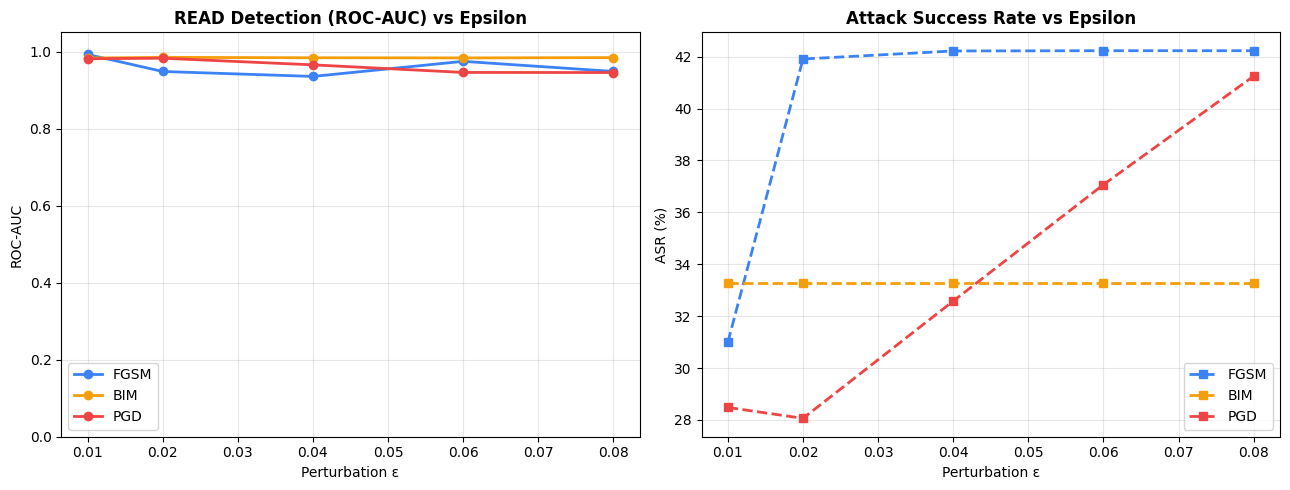

Saved → figure1_robustness_curve.pdf


In [ ]:
# ============================================================
# Step 19 — Oblivious Attacks at Multiple Epsilon Values
# ============================================================
# Produces a robustness curve: ROC-AUC vs epsilon.
# This becomes Figure 1 in your paper.

EPSILONS = [0.01, 0.02, 0.04, 0.06, 0.08]
ALPHA    = 0.002   # step size for BIM / PGD
ITERS    = 5       # iterations for BIM / PGD

robustness_results = []   # list of dicts, one per (attack, epsilon)

for eps in EPSILONS:
    print(f"\n{'='*55}")
    print(f"  Epsilon = {eps}")
    print(f"{'='*55}")

    # ── FGSM ──────────────────────────────────────────────
    X_fgsm = generate_fgsm_attack(
        ids_model,
        X_attack_clean,
        np.ones(len(X_attack_clean)),
        epsilon=eps
    )
    fgsm_asr  = compute_asr(ids_model, X_attack_clean, X_fgsm)
    fgsm_feat = get_read_features(X_fgsm)
    fgsm_res  = evaluate_read_detector(
        read_detector, benign_features, fgsm_feat,
        label=f"FGSM ε={eps}"
    )
    robustness_results.append({
        "attack": "FGSM", "epsilon": eps,
        "asr": fgsm_asr, **fgsm_res
    })

    # ── BIM ───────────────────────────────────────────────
    X_bim = generate_bim_attack(
        ids_model,
        X_attack_clean,
        np.ones(len(X_attack_clean), dtype=int),
        epsilon=eps, alpha=ALPHA, num_iterations=ITERS
    )
    bim_asr  = compute_asr(ids_model, X_attack_clean, X_bim)
    bim_feat = get_read_features(X_bim)
    bim_res  = evaluate_read_detector(
        read_detector, benign_features, bim_feat,
        label=f"BIM ε={eps}"
    )
    robustness_results.append({
        "attack": "BIM", "epsilon": eps,
        "asr": bim_asr, **bim_res
    })

    # ── PGD ───────────────────────────────────────────────
    X_pgd = generate_pgd_attack(
        ids_model,
        X_attack_clean,
        np.ones(len(X_attack_clean), dtype=int),
        epsilon=eps, alpha=ALPHA, num_iterations=ITERS
    )
    pgd_asr  = compute_asr(ids_model, X_attack_clean, X_pgd)
    pgd_feat = get_read_features(X_pgd)
    pgd_res  = evaluate_read_detector(
        read_detector, benign_features, pgd_feat,
        label=f"PGD ε={eps}"
    )
    robustness_results.append({
        "attack": "PGD", "epsilon": eps,
        "asr": pgd_asr, **pgd_res
    })

# ── Summary DataFrame ──────────────────────────────────────
import pandas as pd

robustness_df = pd.DataFrame(robustness_results)
robustness_df["asr_pct"]    = (robustness_df["asr"]     * 100).round(2)
robustness_df["detect_pct"] = (robustness_df["roc_auc"] * 100).round(2)

print("\n\n===== ROBUSTNESS CURVE TABLE =====")
display(robustness_df[[
    "attack", "epsilon", "asr_pct",
    "accuracy", "f1", "roc_auc", "pr_auc"
]])

# ── Plot: ROC-AUC vs Epsilon (paper Figure 1) ─────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"FGSM": "#3b82f6", "BIM": "#f59e0b", "PGD": "#ef4444"}

for attack in ["FGSM", "BIM", "PGD"]:
    sub = robustness_df[robustness_df["attack"] == attack]
    axes[0].plot(sub["epsilon"], sub["roc_auc"],
                 marker="o", label=attack, color=colors[attack], linewidth=2)
    axes[1].plot(sub["epsilon"], sub["asr_pct"],
                 marker="s", label=attack, color=colors[attack],
                 linewidth=2, linestyle="--")

axes[0].set_title("READ Detection (ROC-AUC) vs Epsilon", fontweight="bold")
axes[0].set_xlabel("Perturbation ε"); axes[0].set_ylabel("ROC-AUC")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1.05)

axes[1].set_title("Attack Success Rate vs Epsilon", fontweight="bold")
axes[1].set_xlabel("Perturbation ε"); axes[1].set_ylabel("ASR (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figure1_robustness_curve.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figure1_robustness_curve.pdf")

# **Phase 4**

In [ ]:
# ============================================================
# Step 20 — White-Box Adaptive PGD
# ============================================================
# Attacker knows EVERYTHING: IDS + real R + READ detector.
# We optimize directly against the true reconstruction model.

def generate_whitebox_adaptive_pgd(
    ids_model,
    reconstruction_model,
    feature_extractor,
    X,
    y,
    epsilon=0.01,
    alpha=0.002,
    iterations=5,
    lambda_reconstruction=1.0
):
    """
    White-box adaptive PGD.
    Loss = fool_IDS_loss + lambda * real_reconstruction_loss
    The gradient flows through the true defender's R.
    """
    ids_model.eval()
    reconstruction_model.eval()
    feature_extractor.eval()

    X_tensor  = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    y_tensor  = torch.tensor(y, dtype=torch.float32, device=DEVICE).view(-1, 1)
    original_X = X_tensor.clone().detach()

    # Random start (PGD)
    X_adv = (original_X + torch.empty_like(original_X)
             .uniform_(-epsilon, epsilon)).detach()

    for _ in range(iterations):

        X_adv.requires_grad_(True)

        # 1. IDS fool loss — push toward benign prediction (0)
        logits       = ids_model(X_adv)
        target_benign = torch.zeros_like(y_tensor)
        ids_loss     = F.binary_cross_entropy_with_logits(logits, target_benign)

        # 2. Real reconstruction loss — minimize MedAE signal
        #    by making the adversarial sample look easily reconstructable
        hidden         = feature_extractor(X_adv)
        reconstructed  = reconstruction_model(hidden)
        recon_loss     = F.mse_loss(reconstructed, X_adv)

        # 3. Combined objective
        total_loss = ids_loss + lambda_reconstruction * recon_loss

        ids_model.zero_grad()
        reconstruction_model.zero_grad()
        feature_extractor.zero_grad()

        total_loss.backward()

        # Gradient DESCENT (minimize total_loss)
        gradient = X_adv.grad.sign()
        X_adv    = (X_adv.detach() - alpha * gradient)

        # Project back into epsilon-ball
        delta = torch.clamp(X_adv - original_X, min=-epsilon, max=epsilon)
        X_adv = (original_X + delta).detach()

    return X_adv.cpu().numpy()


# ── Generate white-box adversarial samples ─────────────────

X_whitebox_adv = generate_whitebox_adaptive_pgd(
    ids_model             = ids_model,
    reconstruction_model  = reconstruction_model,
    feature_extractor     = ids_feature_extractor,
    X                     = X_attack_clean,
    y                     = np.ones(len(X_attack_clean), dtype=int),
    epsilon               = 0.01,
    alpha                 = 0.002,
    iterations            = 5,
    lambda_reconstruction = 1.0
)

print("White-box adversarial samples generated.")
print("Shape:", X_whitebox_adv.shape)
print("Max perturbation:", np.abs(X_whitebox_adv - X_attack_clean).max())

# ── IDS evaluation ──────────────────────────────────────────

whitebox_asr = compute_asr(ids_model, X_attack_clean, X_whitebox_adv)
print(f"\nWhite-Box Attack Success Rate: {whitebox_asr:.4%}")

# ── READ metrics + detection ────────────────────────────────

whitebox_features = get_read_features(X_whitebox_adv)

whitebox_medae     = whitebox_features[:, 0]
whitebox_aleatoric = whitebox_features[:, 1]
whitebox_epistemic = whitebox_features[:, 2]
whitebox_entropy   = whitebox_features[:, 3]

print("\nWhite-Box Adversarial READ Metrics")
print("=" * 48)
print(f"  MedAE    → Mean: {whitebox_medae.mean():.6f}  "
      f"Std: {whitebox_medae.std():.6f}")
print(f"  Aleatoric→ Mean: {whitebox_aleatoric.mean():.6f}  "
      f"Std: {whitebox_aleatoric.std():.6f}")
print(f"  Epistemic→ Mean: {whitebox_epistemic.mean():.6f}  "
      f"Std: {whitebox_epistemic.std():.6f}")
print(f"  Entropy  → Mean: {whitebox_entropy.mean():.6f}  "
      f"Std: {whitebox_entropy.std():.6f}")

whitebox_read_results = evaluate_read_detector(
    read_detector,
    benign_features,
    whitebox_features,
    label="White-Box Adaptive PGD  λ=1.0"
)

White-box adversarial samples generated.
Shape: (11125, 79)
Max perturbation: 0.010000075247889817

White-Box Attack Success Rate: 28.8125%

White-Box Adversarial READ Metrics
  MedAE    → Mean: 0.119906  Std: 0.100047
  Aleatoric→ Mean: 0.020242  Std: 0.050564
  Epistemic→ Mean: 0.005280  Std: 0.017498
  Entropy  → Mean: 0.070350  Std: 0.152823

READ Detection [White-Box Adaptive PGD  λ=1.0]
  Accuracy : 0.9032
  Precision: 0.9809
  Recall   : 0.8454
  F1       : 0.9081
  ROC-AUC  : 0.9719
  PR-AUC   : 0.9786
  Confusion Matrix:
[[8354  183]
 [1720 9405]]


# Phase 5


  Lambda = 0.0

READ Detection [Gray-Box λ=0.0]
  Accuracy : 0.9222
  Precision: 0.9816
  Recall   : 0.8789
  F1       : 0.9274
  ROC-AUC  : 0.9829
  PR-AUC   : 0.9865
  Confusion Matrix:
[[8354  183]
 [1347 9778]]

READ Detection [White-Box λ=0.0]
  Accuracy : 0.9295
  Precision: 0.9819
  Recall   : 0.8919
  F1       : 0.9347
  ROC-AUC  : 0.9804
  PR-AUC   : 0.9850
  Confusion Matrix:
[[8354  183]
 [1203 9922]]

  Lambda = 0.1

READ Detection [Gray-Box λ=0.1]
  Accuracy : 0.9061
  Precision: 0.9810
  Recall   : 0.8504
  F1       : 0.9111
  ROC-AUC  : 0.9754
  PR-AUC   : 0.9810
  Confusion Matrix:
[[8354  183]
 [1664 9461]]

READ Detection [White-Box λ=0.1]
  Accuracy : 0.9087
  Precision: 0.9811
  Recall   : 0.8551
  F1       : 0.9138
  ROC-AUC  : 0.9710
  PR-AUC   : 0.9781
  Confusion Matrix:
[[8354  183]
 [1612 9513]]

  Lambda = 0.5

READ Detection [Gray-Box λ=0.5]
  Accuracy : 0.9081
  Precision: 0.9811
  Recall   : 0.8540
  F1       : 0.9132
  ROC-AUC  : 0.9806
  PR-AUC   : 0.98

,attack_type,lambda,asr_pct,read_detect_pct,accuracy,f1,roc_auc,pr_auc
0,Gray-Box,0.0,33.29,98.29,0.922185,0.927440,0.982852,0.986462
1,White-Box,0.0,28.31,98.04,0.929509,0.934715,0.980419,0.985032
2,Gray-Box,0.1,33.93,97.54,0.906062,0.911069,0.975433,0.981000
3,White-Box,0.1,28.47,97.10,0.908707,0.913789,0.970963,0.978062
4,Gray-Box,0.5,33.93,98.06,0.908097,0.913163,0.980644,0.984679
5,White-Box,0.5,28.83,97.12,0.904944,0.909915,0.971168,0.978156
6,Gray-Box,1.0,33.93,98.37,0.913132,0.918309,0.983702,0.986848
7,White-Box,1.0,28.78,97.10,0.904842,0.909810,0.970985,0.977992
8,Gray-Box,2.0,33.93,98.44,0.912318,0.917480,0.984434,0.987378
9,White-Box,2.0,28.70,96.89,0.899603,0.904370,0.968911,0.976494


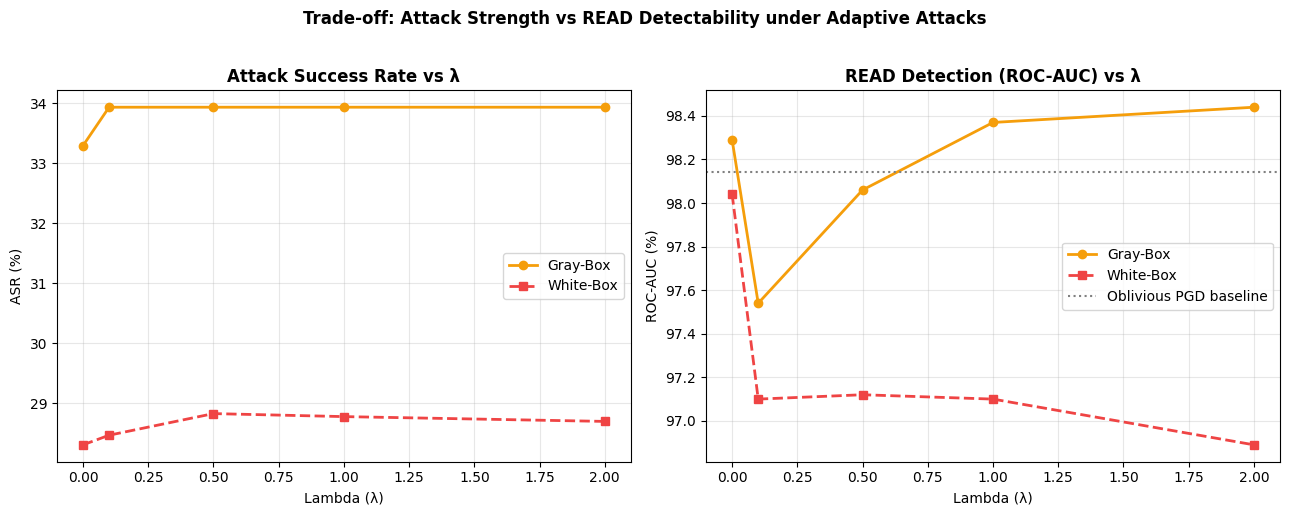

Saved → figure2_lambda_sweep.pdf


In [ ]:
# ============================================================
# Step 21 — Lambda Sweep: Gray-Box and White-Box
# ============================================================
# This produces your KEY paper figure and table.
# λ = 0 → pure IDS fool (no READ-evasion pressure)
# λ ↑   → stronger READ evasion, but IDS success may drop

LAMBDAS = [0.0, 0.1, 0.5, 1.0, 2.0]
SWEEP_EPS   = 0.01
SWEEP_ALPHA = 0.002
SWEEP_ITERS = 5

lambda_sweep_results = []

for lam in LAMBDAS:
    print(f"\n{'='*55}")
    print(f"  Lambda = {lam}")
    print(f"{'='*55}")

    # ── Gray-Box ──────────────────────────────────────────
    X_gb = generate_graybox_adaptive_pgd(
        ids_model             = ids_model,
        surrogate_reconstructor = surrogate_reconstructor,
        X                     = X_attack_clean,
        y                     = np.ones(len(X_attack_clean), dtype=int),
        epsilon               = SWEEP_EPS,
        alpha                 = SWEEP_ALPHA,
        iterations            = SWEEP_ITERS,
        lambda_reconstruction = lam
    )

    gb_asr     = compute_asr(ids_model, X_attack_clean, X_gb)
    gb_feat    = get_read_features(X_gb)
    gb_res     = evaluate_read_detector(
        read_detector, benign_features, gb_feat,
        label=f"Gray-Box λ={lam}"
    )
    lambda_sweep_results.append({
        "attack_type": "Gray-Box",
        "lambda": lam,
        "asr": gb_asr,
        **gb_res
    })

    # ── White-Box ─────────────────────────────────────────
    X_wb = generate_whitebox_adaptive_pgd(
        ids_model             = ids_model,
        reconstruction_model  = reconstruction_model,
        feature_extractor     = ids_feature_extractor,
        X                     = X_attack_clean,
        y                     = np.ones(len(X_attack_clean), dtype=int),
        epsilon               = SWEEP_EPS,
        alpha                 = SWEEP_ALPHA,
        iterations            = SWEEP_ITERS,
        lambda_reconstruction = lam
    )

    wb_asr     = compute_asr(ids_model, X_attack_clean, X_wb)
    wb_feat    = get_read_features(X_wb)
    wb_res     = evaluate_read_detector(
        read_detector, benign_features, wb_feat,
        label=f"White-Box λ={lam}"
    )
    lambda_sweep_results.append({
        "attack_type": "White-Box",
        "lambda": lam,
        "asr": wb_asr,
        **wb_res
    })

# ── Main Paper Table ───────────────────────────────────────

sweep_df = pd.DataFrame(lambda_sweep_results)
sweep_df["asr_pct"]          = (sweep_df["asr"]     * 100).round(2)
sweep_df["read_detect_pct"]  = (sweep_df["roc_auc"] * 100).round(2)

print("\n\n===== LAMBDA SWEEP TABLE (Main Paper Table) =====")
display(sweep_df[[
    "attack_type", "lambda",
    "asr_pct", "read_detect_pct",
    "accuracy", "f1", "roc_auc", "pr_auc"
]])

# ── Main Paper Figure: ASR + READ Detection vs Lambda ─────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
styles = {"Gray-Box": ("#f59e0b", "o", "-"), "White-Box": ("#ef4444", "s", "--")}

for atype, (color, marker, ls) in styles.items():
    sub = sweep_df[sweep_df["attack_type"] == atype]
    axes[0].plot(sub["lambda"], sub["asr_pct"],
                 color=color, marker=marker, linestyle=ls,
                 linewidth=2, label=atype)
    axes[1].plot(sub["lambda"], sub["read_detect_pct"],
                 color=color, marker=marker, linestyle=ls,
                 linewidth=2, label=atype)

# Oblivious PGD baseline (λ=0 equivalent — from robustness_df)
# Use ε=0.01 PGD result as reference line
oblivious_detect = robustness_df[
    (robustness_df["attack"] == "PGD") &
    (robustness_df["epsilon"] == 0.01)
]["roc_auc"].values[0] * 100

axes[1].axhline(oblivious_detect, color="gray", linestyle=":",
                linewidth=1.5, label="Oblivious PGD baseline")

axes[0].set_title("Attack Success Rate vs λ", fontweight="bold")
axes[0].set_xlabel("Lambda (λ)"); axes[0].set_ylabel("ASR (%)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title("READ Detection (ROC-AUC) vs λ", fontweight="bold")
axes[1].set_xlabel("Lambda (λ)"); axes[1].set_ylabel("ROC-AUC (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(
    "Trade-off: Attack Strength vs READ Detectability under Adaptive Attacks",
    fontweight="bold", fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig("figure2_lambda_sweep.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figure2_lambda_sweep.pdf")

# Phase 6

In [ ]:
# ============================================================
# Step 22 — 5-Seed Full Pipeline Loop
# ============================================================
# Re-trains IDS, reconstruction model, and surrogate from
# scratch for each seed. Reports mean ± std across seeds.
# This is required for publication.

SEEDS = [42, 123, 456, 789, 1024]

# We track the most important results across seeds
seed_records = []

for seed in SEEDS:
    print(f"\n{'#'*60}")
    print(f"  SEED = {seed}")
    print(f"{'#'*60}")

    # ── 1. Set seed ────────────────────────────────────────
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # ── 2. Re-split data ───────────────────────────────────
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=seed
    )
    X_vl, X_te, y_vl, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=seed
    )

    # ── 3. Imputation + scaling ────────────────────────────
    from sklearn.impute import SimpleImputer
    imp_s = SimpleImputer(strategy="median")
    sc_s  = MinMaxScaler()

    X_tr_s = sc_s.fit_transform(imp_s.fit_transform(X_tr))
    X_vl_s = sc_s.transform(imp_s.transform(X_vl))
    X_te_s = sc_s.transform(imp_s.transform(X_te))

    # ── 4. Re-train IDS ────────────────────────────────────
    ids_s = IDSModel(X_tr_s.shape[1]).to(DEVICE)
    opt_s = torch.optim.Adam(ids_s.parameters(), lr=0.001)

    tr_tensor = TensorDataset(
        torch.tensor(X_tr_s, dtype=torch.float32),
        torch.tensor(y_tr.values, dtype=torch.float32).reshape(-1, 1)
    )
    tr_loader_s = DataLoader(tr_tensor, batch_size=256, shuffle=True)

    for epoch in range(20):
        train_one_epoch(ids_s, tr_loader_s, criterion, opt_s, DEVICE)

    ids_s.eval()

    # ── 5. Benign correct mask on training set ─────────────
    with torch.no_grad():
        tr_probs = torch.sigmoid(
            ids_s(torch.tensor(X_tr_s, dtype=torch.float32).to(DEVICE))
        ).cpu().numpy().ravel()
    tr_preds = (tr_probs >= 0.5).astype(int)

    benign_mask = (y_tr.values == 0) & (tr_preds == 0)
    X_ben_s     = X_tr_s[benign_mask]

    # ── 6. Re-train reconstruction model ──────────────────
    feat_ext_s = IDSFeatureExtractor(ids_s).to(DEVICE)
    feat_ext_s.eval()

    with torch.no_grad():
        ben_reps = feat_ext_s(
            torch.tensor(X_ben_s, dtype=torch.float32).to(DEVICE)
        ).cpu().numpy()

    rec_s = ReconstructionModel(
        hidden_dim=32, output_dim=X_tr_s.shape[1]
    ).to(DEVICE)
    rec_opt = torch.optim.Adam(rec_s.parameters(), lr=0.001)

    rec_dataset = TensorDataset(
        torch.tensor(ben_reps, dtype=torch.float32),
        torch.tensor(X_ben_s, dtype=torch.float32)
    )
    rec_loader_s = DataLoader(rec_dataset, batch_size=256, shuffle=True)

    best_loss = float("inf"); best_state = None
    for epoch in range(30):
        rec_s.train()
        for h_b, x_b in rec_loader_s:
            h_b, x_b = h_b.to(DEVICE), x_b.to(DEVICE)
            rec_opt.zero_grad()
            loss = reconstruction_criterion(rec_s(h_b), x_b)
            loss.backward(); rec_opt.step()
        rec_s.eval()
        with torch.no_grad():
            val_loss = reconstruction_criterion(
                rec_s(torch.tensor(ben_reps[:200], dtype=torch.float32).to(DEVICE)),
                torch.tensor(X_ben_s[:200], dtype=torch.float32).to(DEVICE)
            ).item()
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in rec_s.state_dict().items()}
    rec_s.load_state_dict(best_state); rec_s.to(DEVICE); rec_s.eval()

    # ── 7. Local get_read_features for this seed ───────────
    def _get_feats(X_np):
        xt = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
        feat_ext_s.eval()
        with torch.no_grad():
            h  = feat_ext_s(xt).cpu()
        rec_s.eval()
        with torch.no_grad():
            recon = rec_s(h.to(DEVICE)).cpu().numpy()
        medae = calculate_medae(X_np, recon)
        al, ep, en = calculate_mc_dropout_uncertainty(ids_s, X_np, n_passes=20)
        return np.column_stack([medae, al, ep, en])

    # ── 8. Get validation attack / benign samples ──────────
    vl_preds_arr = (
        torch.sigmoid(
            ids_s(torch.tensor(X_vl_s, dtype=torch.float32).to(DEVICE)).detach()
        ).cpu().numpy().ravel() >= 0.5
    ).astype(int)

    ben_val_mask = (y_vl.values == 0) & (vl_preds_arr == 0)
    atk_val_mask = (y_vl.values == 1)

    X_ben_val_s = X_vl_s[ben_val_mask]
    X_atk_val_s = X_vl_s[atk_val_mask]

    ben_feats_s = _get_feats(X_ben_val_s)
    atk_feats_s = _get_feats(X_atk_val_s)

    # -- 9. Re-train READ detector (benign vs FGSM adversarial) ------------
    #    Attack-class training samples the IDS classifies correctly
    atk_train_mask = (y_tr.values == 1) & (tr_preds == 1)
    X_atk_train_s  = X_tr_s[atk_train_mask]

    n_pair = min(len(X_atk_train_s), len(X_ben_s))
    rs     = np.random.RandomState(seed)
    X_atk_train_s = X_atk_train_s[rs.choice(len(X_atk_train_s), n_pair, replace=False)]
    X_ben_train_s = X_ben_s[rs.choice(len(X_ben_s), n_pair, replace=False)]

    X_fgsm_train_s = generate_fgsm_attack(
        ids_s, X_atk_train_s,
        np.ones(len(X_atk_train_s), dtype=int),
        epsilon=0.01
    )

    X_rd = np.vstack([_get_feats(X_ben_train_s), _get_feats(X_fgsm_train_s)])
    y_rd = np.concatenate([np.zeros(n_pair, dtype=int), np.ones(n_pair, dtype=int)])

    det_s = RandomForestClassifier(
        n_estimators=200, random_state=seed,
        n_jobs=-1, class_weight="balanced"
    )
    det_s.fit(X_rd, y_rd)

    # ── 10. Oblivious PGD at ε=0.01 ───────────────────────
    X_pgd_s = generate_pgd_attack(
        ids_s, X_atk_val_s,
        np.ones(len(X_atk_val_s), dtype=int),
        epsilon=0.01, alpha=0.002, num_iterations=5
    )
    pgd_asr_s    = compute_asr(ids_s, X_atk_val_s, X_pgd_s)
    pgd_feats_s  = _get_feats(X_pgd_s)
    pgd_res_s    = evaluate_read_detector(
        det_s, ben_feats_s, pgd_feats_s,
        label=f"Seed {seed} | Oblivious PGD"
    )

    # ── 11. White-box adaptive PGD at ε=0.01, λ=1.0 ───────
    X_wb_s = generate_whitebox_adaptive_pgd(
        ids_model            = ids_s,
        reconstruction_model = rec_s,
        feature_extractor    = feat_ext_s,
        X                    = X_atk_val_s,
        y                    = np.ones(len(X_atk_val_s), dtype=int),
        epsilon=0.01, alpha=0.002, iterations=5,
        lambda_reconstruction=1.0
    )
    wb_asr_s    = compute_asr(ids_s, X_atk_val_s, X_wb_s)
    wb_feats_s  = _get_feats(X_wb_s)
    wb_res_s    = evaluate_read_detector(
        det_s, ben_feats_s, wb_feats_s,
        label=f"Seed {seed} | White-Box PGD λ=1.0"
    )

    seed_records.append({
        "seed"               : seed,
        "pgd_asr"            : pgd_asr_s,
        "pgd_read_roc"       : pgd_res_s["roc_auc"],
        "pgd_read_f1"        : pgd_res_s["f1"],
        "wb_asr"             : wb_asr_s,
        "wb_read_roc"        : wb_res_s["roc_auc"],
        "wb_read_f1"         : wb_res_s["f1"],
    })

# ── Statistical Summary ────────────────────────────────────
seed_df = pd.DataFrame(seed_records)

print("\n\n===== STATISTICAL RELIABILITY TABLE =====")
print(f"  Oblivious PGD  ASR          : "
      f"{seed_df['pgd_asr'].mean()*100:.1f} ± "
      f"{seed_df['pgd_asr'].std()*100:.1f} %")
print(f"  Oblivious PGD  READ ROC-AUC : "
      f"{seed_df['pgd_read_roc'].mean()*100:.1f} ± "
      f"{seed_df['pgd_read_roc'].std()*100:.1f} %")
print(f"  Oblivious PGD  READ F1      : "
      f"{seed_df['pgd_read_f1'].mean():.4f} ± "
      f"{seed_df['pgd_read_f1'].std():.4f}")
print()
print(f"  White-Box PGD  ASR          : "
      f"{seed_df['wb_asr'].mean()*100:.1f} ± "
      f"{seed_df['wb_asr'].std()*100:.1f} %")
print(f"  White-Box PGD  READ ROC-AUC : "
      f"{seed_df['wb_read_roc'].mean()*100:.1f} ± "
      f"{seed_df['wb_read_roc'].std()*100:.1f} %")
print(f"  White-Box PGD  READ F1      : "
      f"{seed_df['wb_read_f1'].mean():.4f} ± "
      f"{seed_df['wb_read_f1'].std():.4f}")


############################################################
  SEED = 42
############################################################

READ Detection [Seed 42 | Oblivious PGD]
  Accuracy : 0.9204
  Precision: 0.9721
  Recall   : 0.8804
  F1       : 0.9240
  ROC-AUC  : 0.9813
  PR-AUC   : 0.9842
  Confusion Matrix:
[[8841  281]
 [1330 9795]]

READ Detection [Seed 42 | White-Box PGD λ=1.0]
  Accuracy : 0.9148
  Precision: 0.9718
  Recall   : 0.8701
  F1       : 0.9181
  ROC-AUC  : 0.9798
  PR-AUC   : 0.9828
  Confusion Matrix:
[[8841  281]
 [1445 9680]]

############################################################
  SEED = 123
############################################################

READ Detection [Seed 123 | Oblivious PGD]
  Accuracy : 0.9641
  Precision: 0.9891
  Recall   : 0.9450
  F1       : 0.9665
  ROC-AUC  : 0.9923
  PR-AUC   : 0.9941
  Confusion Matrix:
[[ 9049   116]
 [  612 10513]]

READ Detection [Seed 123 | White-Box PGD λ=1.0]
  Accuracy : 0.9390
  Precision: 0.9885
  

# Phase 7

shap version: 0.52.0
Benign                   n= 2000  mean|SHAP| = MedAE:0.2418  Aleatoric:0.1244  Epistemic:0.0698  Entropy:0.1046
Oblivious FGSM           n= 2000  mean|SHAP| = MedAE:0.2010  Aleatoric:0.1629  Epistemic:0.0891  Entropy:0.1371
Oblivious PGD            n= 2000  mean|SHAP| = MedAE:0.2168  Aleatoric:0.1562  Epistemic:0.0863  Entropy:0.1313
Gray-Box (lam=1.0)       n= 2000  mean|SHAP| = MedAE:0.1970  Aleatoric:0.1364  Epistemic:0.1060  Entropy:0.1170
White-Box (lam=1.0)      n= 2000  mean|SHAP| = MedAE:0.2161  Aleatoric:0.1400  Epistemic:0.0853  Entropy:0.1186


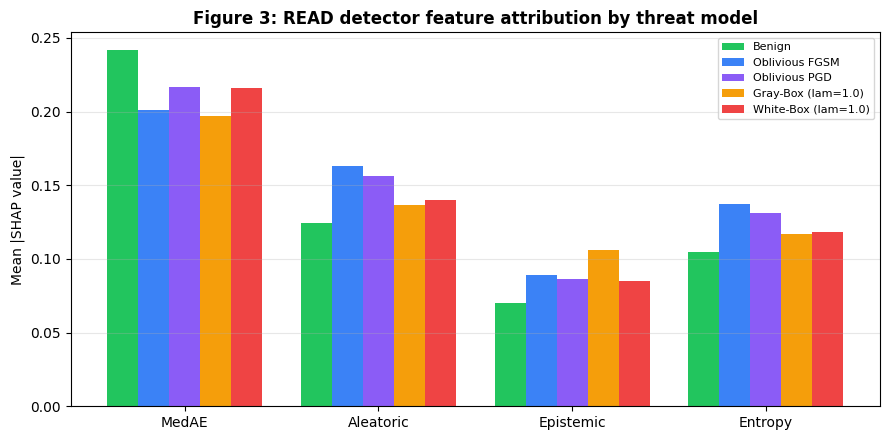


===== SHAP ATTRIBUTION TABLE =====


,MedAE,Aleatoric,Epistemic,Entropy,dominant_feature,MedAE_share,Aleatoric_share,Epistemic_share,Entropy_share
Benign,0.241757,0.124404,0.069824,0.104584,MedAE,0.447,0.230,0.129,0.193
Oblivious FGSM,0.200971,0.162878,0.089092,0.137076,MedAE,0.341,0.276,0.151,0.232
Oblivious PGD,0.216850,0.156155,0.086298,0.131308,MedAE,0.367,0.264,0.146,0.222
Gray-Box (lam=1.0),0.196951,0.136359,0.106017,0.116996,MedAE,0.354,0.245,0.191,0.210
White-Box (lam=1.0),0.216056,0.140013,0.085265,0.118582,MedAE,0.386,0.250,0.152,0.212


Saved -> figure3_shap_importance.pdf, table_shap_attribution.csv


In [ ]:
# ============================================================
# Step 23 — Phase 7: SHAP on the READ detector  (FIXED)
# ============================================================
import shap
import numpy as np
import matplotlib.pyplot as plt

print("shap version:", shap.__version__)

FEATURE_NAMES = ["MedAE", "Aleatoric", "Epistemic", "Entropy"]
SHAP_SUBSAMPLE = 2000          # rows per group; keeps runtime sane
rng_shap = np.random.RandomState(42)

# --- FIX 1: no `data=` (tree_path_dependent), no `check_additivity` here ---
explainer = shap.TreeExplainer(read_detector)


def shap_positive_class(explainer, X, check_additivity=False):
    """
    Return SHAP values for the positive ("adversarial") class as a
    (n_samples, n_features) array, across every SHAP version.
    """
    sv = explainer.shap_values(X, check_additivity=check_additivity)

    if isinstance(sv, list):           # shap < 0.45 -> [class0, class1]
        sv = sv[1]

    sv = np.asarray(sv)

    if sv.ndim == 3:                   # shap >= 0.45 -> (n, n_features, n_classes)
        sv = sv[:, :, 1]

    return sv


def subsample(a, n=SHAP_SUBSAMPLE):
    a = np.asarray(a, dtype=np.float64)
    if len(a) <= n:
        return a
    idx = rng_shap.choice(len(a), size=n, replace=False)
    return a[idx]


# --- Groups to explain -----------------------------------------------------
shap_groups = {
    "Benign":                 benign_features,
    "Oblivious FGSM":         fgsm_features,
    "Oblivious PGD":          pgd_features,
    "Gray-Box (lam=1.0)":     graybox_features,
    "White-Box (lam=1.0)":    whitebox_features,
}

shap_means = {}
shap_raw   = {}

for label, feats in shap_groups.items():
    X_g = subsample(feats)
    sv  = shap_positive_class(explainer, X_g)
    shap_raw[label]   = sv
    shap_means[label] = np.abs(sv).mean(axis=0)
    print(f"{label:<24} n={len(X_g):>5}  mean|SHAP| = "
          + "  ".join(f"{n}:{v:.4f}" for n, v in zip(FEATURE_NAMES, shap_means[label])))

# --- Figure 3: grouped bar chart ------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))

labels = list(shap_means.keys())
x      = np.arange(len(FEATURE_NAMES))
width  = 0.16
palette = ["#22c55e", "#3b82f6", "#8b5cf6", "#f59e0b", "#ef4444"]

for i, lab in enumerate(labels):
    ax.bar(x + (i - (len(labels) - 1) / 2) * width,
           shap_means[lab], width, label=lab, color=palette[i % len(palette)])

ax.set_xticks(x)
ax.set_xticklabels(FEATURE_NAMES)
ax.set_ylabel("Mean |SHAP value|")
ax.set_title("Figure 3: READ detector feature attribution by threat model",
             fontweight="bold")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figure3_shap_importance.pdf", dpi=150, bbox_inches="tight")
plt.show()

# --- Attribution-shift table (this is the number you quote in the text) ----
import pandas as pd

shap_df = pd.DataFrame(shap_means, index=FEATURE_NAMES).T
shap_df["dominant_feature"] = shap_df[FEATURE_NAMES].idxmax(axis=1)

# Share of total attribution carried by each metric
share_df = shap_df[FEATURE_NAMES].div(shap_df[FEATURE_NAMES].sum(axis=1), axis=0)
share_df.columns = [f"{c}_share" for c in FEATURE_NAMES]

shap_table = pd.concat([shap_df, share_df.round(3)], axis=1)
print("\n===== SHAP ATTRIBUTION TABLE =====")
display(shap_table)
shap_table.to_csv("table_shap_attribution.csv")
print("Saved -> figure3_shap_importance.pdf, table_shap_attribution.csv")

/tmp/ipykernel_2791/3965934720.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


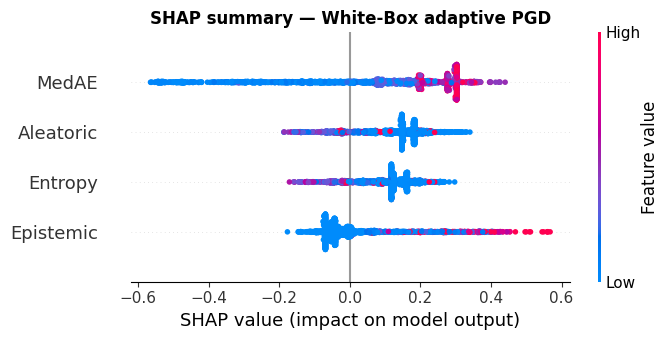

In [ ]:
# ============================================================
# Step 23b — Beeswarm for the strongest threat model (optional)
# ============================================================
X_wb = subsample(whitebox_features, 1500)
sv_wb = shap_positive_class(explainer, X_wb)

shap.summary_plot(
    sv_wb, X_wb,
    feature_names=FEATURE_NAMES,
    show=False,
    plot_size=(7, 3.5)
)
plt.title("SHAP summary — White-Box adaptive PGD", fontweight="bold")
plt.tight_layout()
plt.savefig("figure3b_shap_beeswarm.pdf", dpi=150, bbox_inches="tight")
plt.show()

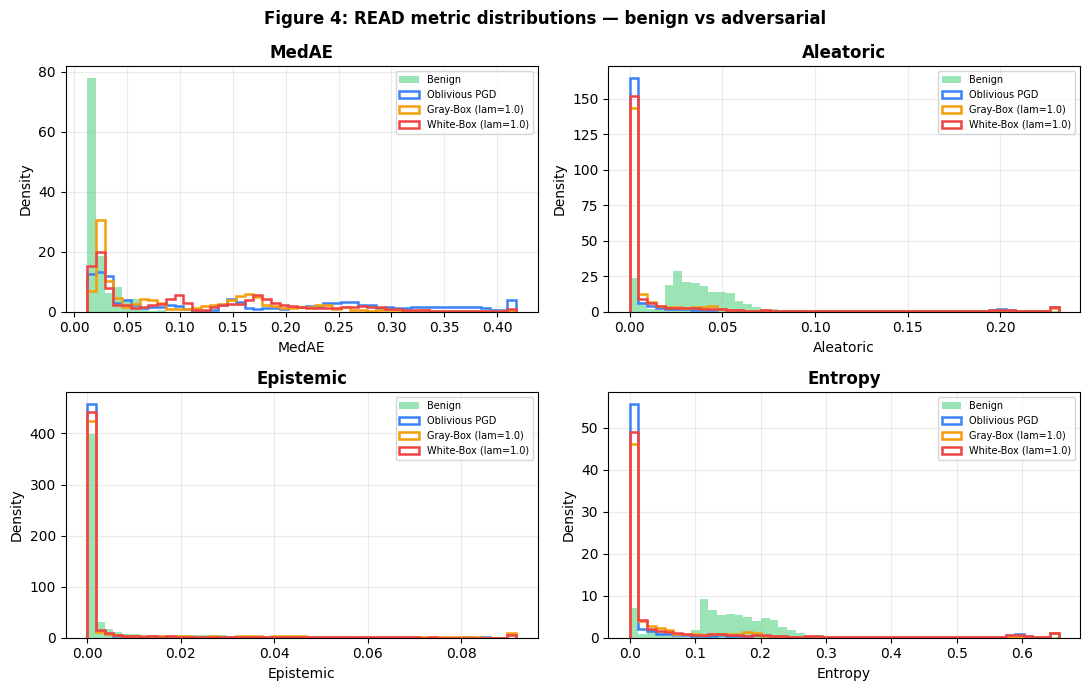


===== METRIC SEPARATION (Cohen's d vs benign) =====


,attack,MedAE_cohens_d,Aleatoric_cohens_d,Epistemic_cohens_d,Entropy_cohens_d
0,Oblivious PGD,1.454,-0.430,0.071,-0.709
1,Gray-Box (lam=1.0),1.284,-0.444,0.225,-0.686
2,White-Box (lam=1.0),1.351,-0.417,0.105,-0.674


In [ ]:
# ============================================================
# Step 24 — Figure 4: READ metric distributions
# ============================================================
dist_groups = {
    "Benign":              benign_features,
    "Oblivious PGD":       pgd_features,
    "Gray-Box (lam=1.0)":  graybox_features,
    "White-Box (lam=1.0)": whitebox_features,
}
dist_colors = {
    "Benign":              "#22c55e",
    "Oblivious PGD":       "#3b82f6",
    "Gray-Box (lam=1.0)":  "#f59e0b",
    "White-Box (lam=1.0)": "#ef4444",
}

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for fi, fname in enumerate(FEATURE_NAMES):
    ax = axes[fi]

    pooled = np.concatenate([g[:, fi] for g in dist_groups.values()])
    lo, hi = np.percentile(pooled, [1, 99])
    if hi <= lo:
        hi = lo + 1e-6
    bins = np.linspace(lo, hi, 50)

    for glabel, gfeats in dist_groups.items():
        vals = np.clip(gfeats[:, fi], lo, hi)
        if glabel == "Benign":
            ax.hist(vals, bins=bins, density=True, alpha=0.45,
                    color=dist_colors[glabel], label=glabel)
        else:
            ax.hist(vals, bins=bins, density=True, histtype="step",
                    linewidth=1.8, color=dist_colors[glabel], label=glabel)

    ax.set_title(f"{fname}", fontweight="bold")
    ax.set_xlabel(fname)
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

plt.suptitle("Figure 4: READ metric distributions — benign vs adversarial",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("figure4_metric_distributions.pdf", dpi=150, bbox_inches="tight")
plt.show()

# --- Separation table: how far each attack moves each metric from benign ---
sep_rows = []
for glabel, gfeats in dist_groups.items():
    if glabel == "Benign":
        continue
    row = {"attack": glabel}
    for fi, fname in enumerate(FEATURE_NAMES):
        b = benign_features[:, fi]
        a = gfeats[:, fi]
        pooled_sd = np.sqrt((b.var() + a.var()) / 2) + 1e-12
        row[f"{fname}_benign_mean"] = round(float(b.mean()), 6)
        row[f"{fname}_attack_mean"] = round(float(a.mean()), 6)
        row[f"{fname}_cohens_d"]    = round(float((a.mean() - b.mean()) / pooled_sd), 3)
    sep_rows.append(row)

separation_df = pd.DataFrame(sep_rows)
print("\n===== METRIC SEPARATION (Cohen's d vs benign) =====")
display(separation_df[["attack"] + [f"{f}_cohens_d" for f in FEATURE_NAMES]])
separation_df.to_csv("table_metric_separation.csv", index=False)

# Phase 8


===== ABLATION TABLE (ROC-AUC) =====


,variant,Oblivious FGSM ROC-AUC,Oblivious BIM ROC-AUC,Oblivious PGD ROC-AUC,Gray-Box (lam=1.0) ROC-AUC,White-Box (lam=1.0) ROC-AUC
0,All 4,0.9926,0.9833,0.9790,0.9832,0.9719
1,-MedAE,0.9650,0.9705,0.9594,0.9487,0.9430
2,-Aleatoric,0.9934,0.9875,0.9832,0.9862,0.9789
3,-Epistemic,0.9884,0.9778,0.9716,0.9638,0.9573
4,-Entropy,0.9934,0.9870,0.9836,0.9858,0.9796
5,MedAE only,0.9655,0.9378,0.9289,0.9169,0.9248
6,Uncertainty only,0.9650,0.9705,0.9594,0.9487,0.9430


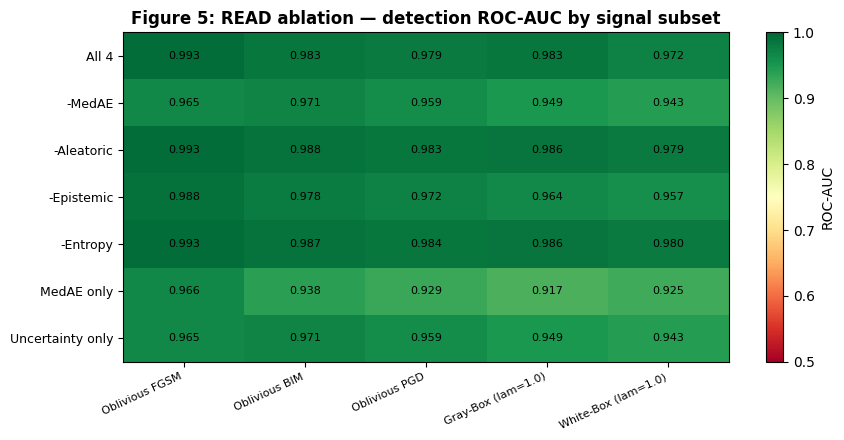

In [ ]:
# ============================================================
# Step 25 — Phase 8: READ signal ablation
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

ABLATION_VARIANTS = {
    "All 4":            [0, 1, 2, 3],
    "-MedAE":           [1, 2, 3],
    "-Aleatoric":       [0, 2, 3],
    "-Epistemic":       [0, 1, 3],
    "-Entropy":         [0, 1, 2],
    "MedAE only":       [0],
    "Uncertainty only": [1, 2, 3],
}

EVAL_SETS = {
    "Oblivious FGSM":      fgsm_features,
    "Oblivious BIM":       bim_features,
    "Oblivious PGD":       pgd_features,
    "Gray-Box (lam=1.0)":  graybox_features,
    "White-Box (lam=1.0)": whitebox_features,
}

ablation_rows = []

for vname, cols in ABLATION_VARIANTS.items():
    det = RandomForestClassifier(
        n_estimators=200, random_state=SEED,
        n_jobs=-1, class_weight="balanced"
    )
    det.fit(X_read_detector[:, cols], y_read_detector)

    row = {"variant": vname, "n_features": len(cols)}

    for aname, afeats in EVAL_SETS.items():
        X_eval = np.vstack([benign_features[:, cols], afeats[:, cols]])
        y_eval = np.concatenate([
            np.zeros(len(benign_features), dtype=int),
            np.ones(len(afeats), dtype=int)
        ])
        prob = det.predict_proba(X_eval)[:, 1]
        pred = det.predict(X_eval)

        row[f"{aname} ROC-AUC"] = round(roc_auc_score(y_eval, prob), 4)
        row[f"{aname} F1"]      = round(f1_score(y_eval, pred, zero_division=0), 4)

    ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows)
print("\n===== ABLATION TABLE (ROC-AUC) =====")
display(ablation_df[["variant"] + [f"{a} ROC-AUC" for a in EVAL_SETS]])
ablation_df.to_csv("table_ablation.csv", index=False)

# --- Figure 5: ablation heatmap -------------------------------------------
roc_cols = [f"{a} ROC-AUC" for a in EVAL_SETS]
M = ablation_df[roc_cols].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(M, cmap="RdYlGn", vmin=0.5, vmax=1.0, aspect="auto")

ax.set_xticks(np.arange(len(EVAL_SETS)))
ax.set_xticklabels(list(EVAL_SETS.keys()), rotation=25, ha="right", fontsize=8)
ax.set_yticks(np.arange(len(ablation_df)))
ax.set_yticklabels(ablation_df["variant"], fontsize=9)

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i, j]:.3f}", ha="center", va="center", fontsize=8)

ax.set_title("Figure 5: READ ablation — detection ROC-AUC by signal subset",
             fontweight="bold")
fig.colorbar(im, ax=ax, label="ROC-AUC")
plt.tight_layout()
plt.savefig("figure5_ablation_heatmap.pdf", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# Step 26 — Adaptive PGD v2 (gradient-normalised, MedAE-targeted)
# ============================================================
import torch
import torch.nn.functional as F


def _mc_entropy_differentiable(model, X, n_passes=8):
    """
    Predictive entropy under MC dropout, kept in the autograd graph.
    Dropout is enabled (model.train()) but no_grad is NOT used.
    """
    was_training = model.training
    model.train()                       # enable dropout masks

    probs = []
    for _ in range(n_passes):
        probs.append(torch.sigmoid(model(X)).squeeze(1))
    p = torch.stack(probs, dim=0).mean(dim=0).clamp(1e-6, 1 - 1e-6)

    ent = -(p * torch.log(p) + (1 - p) * torch.log(1 - p))

    if not was_training:
        model.eval()
    return ent                          # (N,)


def generate_adaptive_pgd_v2(
    ids_model,
    X,
    epsilon=0.01,
    alpha=0.001,
    iterations=40,
    lam=1.0,                   # weight on the reconstruction (MedAE) term
    gamma=0.0,                 # weight on the entropy term (0 = off)
    mode="whitebox",           # "whitebox" | "graybox" | "oblivious"
    reconstruction_model=None, # defender R   (whitebox)
    feature_extractor=None,    # defender F   (whitebox)
    surrogate_reconstructor=None,  # attacker's AE (graybox)
    mc_passes=8,
    clamp_range=(0.0, 1.0),
    random_start=True,
    verbose=False
):
    """
    Adaptive PGD against IDS + READ.

    Per iteration:
      g_ids  = d/dX  [ BCE(ids(X), benign) ]            per-sample, L2-normalised
      g_rec  = d/dX  [ median_j |R(F(X))_j - X_j| ]     per-sample, L2-normalised
      g_ent  = d/dX  [ H(MC-dropout p(X)) ]             per-sample, L2-normalised
      g      = g_ids + lam * g_rec + gamma * g_ent
      X     <- clip_eps( X - alpha * sign(g) )

    Normalising each term before weighting is what makes `lam` a meaningful
    knob: without it, sign() collapses the whole sum onto whichever term
    happens to have the larger raw magnitude.
    """
    ids_model.eval()
    if reconstruction_model is not None:
        reconstruction_model.eval()
    if feature_extractor is not None:
        feature_extractor.eval()
    if surrogate_reconstructor is not None:
        surrogate_reconstructor.eval()

    X0 = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    original = X0.clone().detach()

    if random_start:
        X_adv = (original + torch.empty_like(original)
                 .uniform_(-epsilon, epsilon)).detach()
    else:
        X_adv = original.clone().detach()

    if clamp_range is not None:
        X_adv = X_adv.clamp(*clamp_range).detach()

    def _norm(g):
        return g / (g.flatten(1).norm(dim=1).view(-1, 1) + 1e-12)

    for it in range(iterations):
        X_adv.requires_grad_(True)

        # ---- 1. IDS term: push toward the benign class -------------------
        logits   = ids_model(X_adv)
        target   = torch.zeros_like(logits)
        ids_loss = F.binary_cross_entropy_with_logits(
            logits, target, reduction="sum")          # per-sample, not averaged
        g_ids = torch.autograd.grad(
            ids_loss, X_adv, retain_graph=False)[0]
        g_total = _norm(g_ids)

        # ---- 2. Reconstruction term: minimise MedAE directly -------------
        if lam != 0.0 and mode != "oblivious":
            X_r = X_adv.detach().requires_grad_(True)

            if mode == "whitebox":
                recon = reconstruction_model(feature_extractor(X_r))
            elif mode == "graybox":
                recon = surrogate_reconstructor(X_r)
            else:
                raise ValueError("mode must be whitebox/graybox/oblivious")

            medae = (recon - X_r).abs().median(dim=1).values   # (N,)
            g_rec = torch.autograd.grad(medae.sum(), X_r)[0]
            g_total = g_total + lam * _norm(g_rec)

        # ---- 3. Entropy term: make the model confident -------------------
        if gamma != 0.0:
            X_e = X_adv.detach().requires_grad_(True)
            ent = _mc_entropy_differentiable(ids_model, X_e, n_passes=mc_passes)
            g_ent = torch.autograd.grad(ent.sum(), X_e)[0]
            g_total = g_total + gamma * _norm(g_ent)

        # ---- 4. Step, project, clamp -------------------------------------
        X_adv = (X_adv.detach() - alpha * g_total.sign())
        delta = torch.clamp(X_adv - original, min=-epsilon, max=epsilon)
        X_adv = (original + delta)
        if clamp_range is not None:
            X_adv = X_adv.clamp(*clamp_range)
        X_adv = X_adv.detach()

        if verbose and (it + 1) % 10 == 0:
            print(f"    iter {it+1}/{iterations}")

    return X_adv.cpu().numpy()


print("generate_adaptive_pgd_v2 defined.")

generate_adaptive_pgd_v2 defined.


In [ ]:
# ============================================================
# Step 27 — Does lambda actually move MedAE? (sanity check)
# ============================================================
SANITY_N = 2000
idx_s = np.random.RandomState(0).choice(len(X_attack_clean), SANITY_N, replace=False)
X_small = X_attack_clean[idx_s]

benign_medae_mean = benign_features[:, 0].mean()
print(f"Benign MedAE mean (reference): {benign_medae_mean:.6f}\n")

print(f"{'lam':>6} | {'ASR':>7} | {'MedAE mean':>11} | {'Entropy mean':>12}")
print("-" * 46)

for lam in [0.0, 0.5, 1.0, 2.0, 5.0, 10.0]:
    X_adv_s = generate_adaptive_pgd_v2(
        ids_model, X_small,
        epsilon=0.01, alpha=0.001, iterations=40,
        lam=lam, gamma=0.0, mode="whitebox",
        reconstruction_model=reconstruction_model,
        feature_extractor=ids_feature_extractor
    )
    asr_s   = compute_asr(ids_model, X_small, X_adv_s)
    feats_s = get_read_features(X_adv_s)
    print(f"{lam:>6.1f} | {asr_s*100:>6.2f}% | {feats_s[:,0].mean():>11.6f} | "
          f"{feats_s[:,3].mean():>12.6f}")

print("\nExpected: MedAE mean decreases monotonically toward the benign reference")
print("as lam grows, while ASR falls. If MedAE is flat, the attack is still broken.")

Benign MedAE mean (reference): 0.023604

   lam |     ASR |  MedAE mean | Entropy mean
----------------------------------------------
   0.0 |  14.98% |    0.119496 |     0.097118
   0.5 |  14.62% |    0.116827 |     0.102717
   1.0 |  14.98% |    0.116925 |     0.101094
   2.0 |   9.45% |    0.119918 |     0.124786
   5.0 |   6.82% |    0.122309 |     0.126693
  10.0 |   6.35% |    0.122538 |     0.127587

Expected: MedAE mean decreases monotonically toward the benign reference
as lam grows, while ASR falls. If MedAE is flat, the attack is still broken.



  lambda = 0.0

READ Detection [Gray-Box lam=0.0]
  Accuracy : 0.8934
  Precision: 0.9805
  Recall   : 0.8281
  F1       : 0.8979
  ROC-AUC  : 0.9706
  PR-AUC   : 0.9777
  Confusion Matrix:
[[8354  183]
 [1912 9213]]

READ Detection [White-Box lam=0.0]
  Accuracy : 0.8938
  Precision: 0.9805
  Recall   : 0.8288
  F1       : 0.8983
  ROC-AUC  : 0.9698
  PR-AUC   : 0.9772
  Confusion Matrix:
[[8354  183]
 [1905 9220]]

READ Detection [White-Box + Entropy lam=0.0]
  Accuracy : 0.8874
  Precision: 0.9803
  Recall   : 0.8174
  F1       : 0.8915
  ROC-AUC  : 0.9779
  PR-AUC   : 0.9824
  Confusion Matrix:
[[8354  183]
 [2031 9094]]

  lambda = 0.5

READ Detection [Gray-Box lam=0.5]
  Accuracy : 0.8965
  Precision: 0.9806
  Recall   : 0.8334
  F1       : 0.9011
  ROC-AUC  : 0.9707
  PR-AUC   : 0.9778
  Confusion Matrix:
[[8354  183]
 [1853 9272]]

READ Detection [White-Box lam=0.5]
  Accuracy : 0.8895
  Precision: 0.9804
  Recall   : 0.8212
  F1       : 0.8938
  ROC-AUC  : 0.9693
  PR-AUC   :

,attack_type,lambda,asr_pct,read_roc_pct,f1,pr_auc,medae_mean,entropy_mean
0,Gray-Box,0.0,16.18,97.06,0.897909,0.977718,0.116442,0.102446
1,White-Box,0.0,15.87,96.98,0.898285,0.977176,0.116444,0.102797
2,White-Box + Entropy,0.0,8.40,97.79,0.891481,0.982386,0.125795,0.089759
3,Gray-Box,0.5,20.93,97.07,0.901069,0.977816,0.117317,0.087845
4,White-Box,0.5,16.24,96.93,0.893759,0.976656,0.113867,0.102868
5,White-Box + Entropy,0.5,12.59,96.57,0.875329,0.973708,0.116266,0.095256
6,Gray-Box,1.0,22.30,96.70,0.902669,0.975215,0.118488,0.092292
7,White-Box,1.0,15.85,96.87,0.902509,0.976287,0.113954,0.103435
8,White-Box + Entropy,1.0,12.32,97.02,0.879731,0.976897,0.116517,0.094855
9,Gray-Box,2.0,23.83,96.73,0.894678,0.975176,0.120412,0.099646


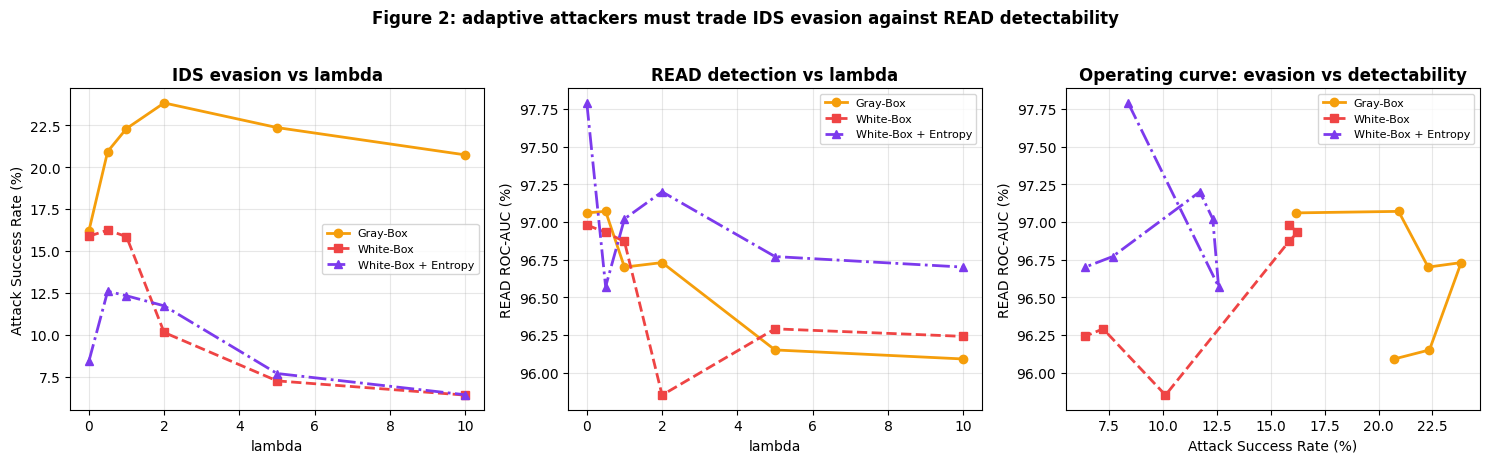

In [ ]:
# ============================================================
# Step 28 — Lambda sweep v2 (gray-box / white-box / white-box+entropy)
# ============================================================
LAMBDAS_V2 = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0]
SWEEP_EPS   = 0.01
SWEEP_ALPHA = 0.001
SWEEP_ITERS = 40
GAMMA_FULL  = 1.0      # entropy weight for the "full adaptive" attacker

sweep_v2_rows = []

for lam in LAMBDAS_V2:
    print(f"\n{'='*58}\n  lambda = {lam}\n{'='*58}")

    configs = {
        "Gray-Box": dict(
            mode="graybox",
            surrogate_reconstructor=surrogate_reconstructor,
            gamma=0.0),
        "White-Box": dict(
            mode="whitebox",
            reconstruction_model=reconstruction_model,
            feature_extractor=ids_feature_extractor,
            gamma=0.0),
        "White-Box + Entropy": dict(
            mode="whitebox",
            reconstruction_model=reconstruction_model,
            feature_extractor=ids_feature_extractor,
            gamma=GAMMA_FULL),
    }

    for cname, kwargs in configs.items():
        X_adv = generate_adaptive_pgd_v2(
            ids_model, X_attack_clean,
            epsilon=SWEEP_EPS, alpha=SWEEP_ALPHA,
            iterations=SWEEP_ITERS, lam=lam, **kwargs
        )

        asr   = compute_asr(ids_model, X_attack_clean, X_adv)
        feats = get_read_features(X_adv)
        res   = evaluate_read_detector(
            read_detector, benign_features, feats,
            label=f"{cname} lam={lam}")

        sweep_v2_rows.append({
            "attack_type": cname,
            "lambda": lam,
            "asr": asr,
            "medae_mean": float(feats[:, 0].mean()),
            "entropy_mean": float(feats[:, 3].mean()),
            **res
        })

sweep_v2_df = pd.DataFrame(sweep_v2_rows)
sweep_v2_df["asr_pct"]      = (sweep_v2_df["asr"] * 100).round(2)
sweep_v2_df["read_roc_pct"] = (sweep_v2_df["roc_auc"] * 100).round(2)

print("\n\n===== LAMBDA SWEEP v2 (MAIN PAPER TABLE) =====")
display(sweep_v2_df[["attack_type", "lambda", "asr_pct", "read_roc_pct",
                     "f1", "pr_auc", "medae_mean", "entropy_mean"]])
sweep_v2_df.to_csv("table_lambda_sweep_v2.csv", index=False)

# --- Figure 2 (revised): the evasion/detection trade-off ------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
styles = {
    "Gray-Box":            ("#f59e0b", "o", "-"),
    "White-Box":           ("#ef4444", "s", "--"),
    "White-Box + Entropy": ("#7c3aed", "^", "-."),
}

for atype, (color, marker, ls) in styles.items():
    sub = sweep_v2_df[sweep_v2_df["attack_type"] == atype].sort_values("lambda")
    axes[0].plot(sub["lambda"], sub["asr_pct"], color=color, marker=marker,
                 linestyle=ls, linewidth=2, label=atype)
    axes[1].plot(sub["lambda"], sub["read_roc_pct"], color=color, marker=marker,
                 linestyle=ls, linewidth=2, label=atype)
    axes[2].plot(sub["asr_pct"], sub["read_roc_pct"], color=color, marker=marker,
                 linestyle=ls, linewidth=2, label=atype)

axes[0].set_xlabel("lambda"); axes[0].set_ylabel("Attack Success Rate (%)")
axes[0].set_title("IDS evasion vs lambda", fontweight="bold")

axes[1].set_xlabel("lambda"); axes[1].set_ylabel("READ ROC-AUC (%)")
axes[1].set_title("READ detection vs lambda", fontweight="bold")

axes[2].set_xlabel("Attack Success Rate (%)"); axes[2].set_ylabel("READ ROC-AUC (%)")
axes[2].set_title("Operating curve: evasion vs detectability", fontweight="bold")

for ax in axes:
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Figure 2: adaptive attackers must trade IDS evasion against READ detectability",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figure2_lambda_sweep_v2.pdf", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# Step 29 — Export all results
# ============================================================
import os

OUT_DIR = "paper_results"
os.makedirs(OUT_DIR, exist_ok=True)

exports = {
    "robustness_curve": globals().get("robustness_df"),
    "lambda_sweep_v1":  globals().get("sweep_df"),
    "lambda_sweep_v2":  globals().get("sweep_v2_df"),
    "seed_reliability": globals().get("seed_df"),
    "ablation":         globals().get("ablation_df"),
    "shap_attribution": globals().get("shap_table"),
    "metric_separation": globals().get("separation_df"),
}

for name, df in exports.items():
    if df is None:
        print(f"  [skip] {name} — not in kernel")
        continue
    path = os.path.join(OUT_DIR, f"{name}.csv")
    df.to_csv(path, index=(name == "shap_attribution"))
    print(f"  [ok]   {name} -> {path}  ({df.shape[0]} rows)")

# --- Headline numbers -----------------------------------------------------
print("\n" + "=" * 58)
print("  HEADLINE NUMBERS FOR THE ABSTRACT")
print("=" * 58)

if "sweep_v2_df" in globals():
    for atype in sweep_v2_df["attack_type"].unique():
        sub = sweep_v2_df[sweep_v2_df["attack_type"] == atype]
        best_evasion = sub.loc[sub["roc_auc"].idxmin()]
        print(f"\n  {atype}")
        print(f"    lam=0   : ASR {sub[sub['lambda']==0]['asr_pct'].values[0]:.1f}%  "
              f"READ {sub[sub['lambda']==0]['read_roc_pct'].values[0]:.1f}%")
        print(f"    best evasion (lam={best_evasion['lambda']}): "
              f"ASR {best_evasion['asr_pct']:.1f}%  "
              f"READ {best_evasion['read_roc_pct']:.1f}%")

if "ablation_df" in globals():
    wb_col = [c for c in ablation_df.columns if c.startswith("White-Box") and "ROC" in c]
    if wb_col:
        worst = ablation_df.loc[ablation_df[wb_col[0]].idxmin()]
        print(f"\n  Most load-bearing signal (largest drop when removed, white-box): "
              f"{worst['variant']}  ROC-AUC {worst[wb_col[0]]:.3f}")

print("\nDone.")

  [ok]   robustness_curve -> paper_results/robustness_curve.csv  (15 rows)
  [ok]   lambda_sweep_v1 -> paper_results/lambda_sweep_v1.csv  (10 rows)
  [ok]   lambda_sweep_v2 -> paper_results/lambda_sweep_v2.csv  (18 rows)
  [ok]   seed_reliability -> paper_results/seed_reliability.csv  (5 rows)
  [ok]   ablation -> paper_results/ablation.csv  (7 rows)
  [ok]   shap_attribution -> paper_results/shap_attribution.csv  (5 rows)
  [ok]   metric_separation -> paper_results/metric_separation.csv  (3 rows)

  HEADLINE NUMBERS FOR THE ABSTRACT

  Gray-Box
    lam=0   : ASR 16.2%  READ 97.1%
    best evasion (lam=10.0): ASR 20.7%  READ 96.1%

  White-Box
    lam=0   : ASR 15.9%  READ 97.0%
    best evasion (lam=2.0): ASR 10.1%  READ 95.8%

  White-Box + Entropy
    lam=0   : ASR 8.4%  READ 97.8%
    best evasion (lam=0.5): ASR 12.6%  READ 96.6%

  Most load-bearing signal (largest drop when removed, white-box): MedAE only  ROC-AUC 0.925

Done.
